# Causal Concept Bottleneck Model (CBM) on Temporal Interaction Datasets

This notebook implements a **Causal Concept Bottleneck Model (CBM)** for **node classification** on temporal interaction networks.

Supported datasets (set `dataset_key` in the config cell):

- `temporal_clusters` (synthetic, used in pathpyG examples)
- `highschool` / `sp_high_school` (netzschleuder) — labels: `class` (or `gender`)
- `office` / `sp_office` (netzschleuder) — labels: `department`
- `hospital` / `sp_hospital` (netzschleuder) — labels: `status`

Pipeline:

1. Load a dataset (via the same loader pattern used in the DBGNN notebook).
2. Build first-order graph **g** and second-order transition graph **g2**.
3. Discover concepts (node groups) from **g** using mask-based optimization.
4. Build causal concept features from (**g**, **g2**).
5. Train a sparse CBM head (L1 Logistic Regression).
6. Evaluate and explain predictions.

> Tip: The structure mirrors `01_train_dbgnn_and_node2vec.ipynb`, so switching datasets is mostly a config change.

This notebook is tuned from measured searches to balance predictive accuracy, concept faithfulness, and visual interpretability.


In [1]:
from pathlib import Path
import sys

# Resolve project root and src/ path for standalone and legacy layouts.
CWD = Path.cwd().resolve()
candidates = [CWD / "src", CWD / "julia_code" / "src", CWD.parent / "src"]
SRC = next((p for p in candidates if (p / "cbm").exists() and (p / "data").exists()), None)
if SRC is None:
    raise RuntimeError(f"Could not find src directory. Checked: {candidates}")

ROOT = SRC.parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("ROOT:", ROOT)
print("SRC added to sys.path:", SRC)


ROOT: /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/IV_cbm_implementation
SRC added to sys.path: /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/IV_cbm_implementation/src


In [2]:
# --- Imports + helper utilities (moved to src/cbm/core.py) ---
import cbm.core as _cbm_core

# Export all core symbols (including internal helpers prefixed with `_`) so
# legacy notebook cells continue to work unchanged.
for _name, _obj in _cbm_core.__dict__.items():
    if _name.startswith("__"):
        continue
    globals()[_name] = _obj


In [3]:
# --- Config ---
from cbm.presets import (
    apply_run_preset,
    build_dataset_profiles,
    canonicalize_dataset_key,
)

seed = 42

# ---------------------------------------------------------------------
# Dataset selection
# ---------------------------------------------------------------------
# Choose one of:
#   "temporal_clusters", "highschool", "office", "hospital", "sms"
# Aliases:
#   "sp_high_school" -> "highschool"
#   "sp_office"      -> "office"
#   "sp_hospital"    -> "hospital"
dataset_key = "hospital"

# For netzschleuder datasets you can override the label attribute here.
# - highschool: "class" (default) or "gender"
# - office: "department"
# - hospital: "status"
target_attr_override = None  # e.g., "gender"

# Optional: apply a best-known preset.
# Set to one of: "office_best", "highschool_class_best", "highschool_gender_best",
# "temporal_clusters_best", "sms_best", "sms_faith_plus", "sms_faith_sparse",
# "sms_faith_search", "sms_compromise", "hospital_best"
run_preset_key = "hospital_best"

DATASET_PROFILES = build_dataset_profiles(root=ROOT, cwd=CWD)

dataset_key, target_attr_override, run_preset = apply_run_preset(
    dataset_key=dataset_key,
    target_attr_override=target_attr_override,
    run_preset_key=run_preset_key,
)
if run_preset is not None:
    print(f"Using preset: {run_preset_key} -> dataset={dataset_key}, target_attr={target_attr_override}")

dataset_key = canonicalize_dataset_key(dataset_key)
assert dataset_key in DATASET_PROFILES, f"Unknown dataset_key: {dataset_key}"
profile = DATASET_PROFILES[dataset_key]

# ---------------------------------------------------------------------
# Mask-group concept settings
# ---------------------------------------------------------------------
N_GROUPS = int(run_preset.n_groups) if run_preset is not None else 10
USE_BOTH_LAYOUT_CONCEPTS = True
INCLUDE_STRENGTHS = bool(run_preset.include_strengths) if run_preset is not None else True

# Mask-group learning hyperparameters
MASK_STEPS = int(run_preset.mask_steps) if run_preset is not None else 900
MASK_LR = float(run_preset.mask_lr) if run_preset is not None else 0.08
MASK_TEMP_START = float(run_preset.mask_temp_start) if run_preset is not None else 2.0
MASK_TEMP_END = float(run_preset.mask_temp_end) if run_preset is not None else 0.45
MASK_ENTROPY_REG = float(run_preset.mask_entropy_reg) if run_preset is not None else 0.004
MASK_SMOOTH_REG = float(run_preset.mask_smooth_reg) if run_preset is not None else 0.03
MASK_BALANCE_REG = float(run_preset.mask_balance_reg) if run_preset is not None else 0.02
MASK_CLASS_WEIGHT_BALANCED = bool(run_preset.mask_class_weight_balanced) if run_preset is not None else False

# Legacy alias used by downstream cells for active concept view selection.
SPRING_LAYOUT_ON_G2 = False

# Concept engineering / anti-collapse controls
USE_CONCEPT_PRUNING = True
CONCEPT_MIN_VAR = 1e-7
CONCEPT_MAX_CORR = float(run_preset.concept_max_corr) if run_preset is not None else 0.995
BALANCE_CONCEPT_FAMILIES = bool(run_preset.balance_concept_families) if run_preset is not None else False

# Sparse model search objective
L1_RATIOS = tuple(run_preset.l1_ratios) if run_preset is not None else (0.8, 1.0)
TARGET_ACTIVE_CONCEPTS = int(run_preset.target_active_concepts) if run_preset is not None else 8
DIVERSITY_WEIGHT = float(run_preset.diversity_weight) if run_preset is not None else 0.03
HEAD_CLASS_WEIGHT_BALANCED = bool(run_preset.head_class_weight_balanced) if run_preset is not None else False

# Optional fixed head hint from preset (informative).
FIXED_HEAD_FROM_PRESET = None if run_preset is None else {
    "C": float(run_preset.best_head_C),
    "l1_ratio": float(run_preset.best_head_l1_ratio),
}

# Optional label cleanup for rare classes.
DROP_RARE_LABEL_MIN_COUNT = int(run_preset.drop_rare_label_min_count) if run_preset is not None else 0

# Concept views
LOCAL_ACTIVE_VIEW = "all"   # "layout" | "all"
FAITH_ACTIVE_VIEW = "all"   # "layout" | "all"

# Auto-pick a node with strong faithfulness profile for visualization.
AUTO_SELECT_EXPLAIN_NODE = True
# this will be overwritten if the previous is true
node_internal = 10

# If we need to build g2 from raw temporal edges
DELTA = 1

# Data splits
# - test_size: fraction of labeled nodes held out for final test.
# - val_size: fraction of (train+val pool) used for validation selection.
test_size = 0.30
val_size = 0.20

# Validation search controls for concept discovery.
ENABLE_CONCEPT_VAL_SEARCH = bool(run_preset.enable_concept_val_search) if run_preset is not None else True
CONCEPT_SEARCH_SKIP_DATASETS = set(run_preset.concept_search_skip_datasets) if run_preset is not None else {"office"}
CONCEPT_SEARCH_MAX_CANDIDATES = int(run_preset.concept_search_max_candidates) if run_preset is not None else 24

# Faithfulness audit controls.
FAITH_AUDIT_MAX_K = int(run_preset.faith_audit_max_k) if run_preset is not None else 18
FAITH_AUDIT_MAX_NODES = int(run_preset.faith_audit_max_nodes) if run_preset is not None else 20

# Optional faithfulness-aware concept-search objective shaping.
FAITH_SELECTION_WEIGHT = float(run_preset.faith_selection_weight) if run_preset is not None else 0.0
FAITH_SELECTION_FLIP_WEIGHT = float(run_preset.faith_selection_flip_weight) if run_preset is not None else 0.0
FAITH_SELECTION_MAX_NODES = int(run_preset.faith_selection_max_nodes) if run_preset is not None else 12
FAITH_SELECTION_MAX_K = int(run_preset.faith_selection_max_k) if run_preset is not None else 12
FAITH_SELECTION_RANDOM_TRIALS = int(run_preset.faith_selection_random_trials) if run_preset is not None else 16

# Search grids (mask-group configs). Use None for automatic local grids around base values.
CONCEPT_SEARCH_N_GROUPS = None               # e.g., (8, 10, 12)
MASK_SEARCH_SMOOTH_REGS = None               # e.g., (0.01, 0.03, 0.06)
MASK_SEARCH_ENTROPY_REGS = None              # e.g., (0.002, 0.004, 0.008)
MASK_SEARCH_BALANCE_REGS = None              # e.g., (0.01, 0.02)
MASK_SEARCH_CLASS_WEIGHT = None              # e.g., (False, True)

# LogisticRegression search space (selected on val split)
MAX_ITER = 8000
Cs = np.logspace(-2, 1, 7)

print("dataset_key:", dataset_key)
if target_attr_override is not None:
    print("target_attr_override:", target_attr_override)
if FIXED_HEAD_FROM_PRESET is not None:
    print("fixed head hint from preset:", FIXED_HEAD_FROM_PRESET)
if DROP_RARE_LABEL_MIN_COUNT > 0:
    print("drop rare labels min count:", DROP_RARE_LABEL_MIN_COUNT)
print("head_class_weight_balanced:", bool(HEAD_CLASS_WEIGHT_BALANCED))
if FAITH_SELECTION_WEIGHT > 0 or FAITH_SELECTION_FLIP_WEIGHT > 0:
    print(
        "faith_selection_weights:",
        {
            "auc": float(FAITH_SELECTION_WEIGHT),
            "flip": float(FAITH_SELECTION_FLIP_WEIGHT),
            "max_nodes": int(FAITH_SELECTION_MAX_NODES),
            "max_k": int(FAITH_SELECTION_MAX_K),
            "random_trials": int(FAITH_SELECTION_RANDOM_TRIALS),
        },
    )


Using preset: hospital_best -> dataset=hospital, target_attr=status
dataset_key: hospital
target_attr_override: status
fixed head hint from preset: {'C': 1.0, 'l1_ratio': 1.0}
head_class_weight_balanced: False


In [4]:
# --- Load dataset (uses the same loader as the DBGNN notebook) ---
try:
    import torch
    from data.registry import get_dataset_loader, DATASET_REGISTRY
    from runtime_utils import get_device, set_seed
    from cbm.notebook_utils import (
        resolve_dataset_name,
        label_count_map,
        load_dataset_with_retry,
        normalize_loader_kwargs,
    )
except Exception as e:
    raise RuntimeError(
        "Could not import dataset/runtime modules or torch.\n"
        "This notebook expects the same environment as `01_train_dbgnn_and_node2vec.ipynb`."
    ) from e

set_seed(seed)
device = get_device()

dataset_name = resolve_dataset_name(
    candidates=list(profile.candidates),
    dataset_registry=DATASET_REGISTRY,
    get_dataset_loader=get_dataset_loader,
)

dataset_kwargs = normalize_loader_kwargs(dict(profile.dataset_kwargs))
_default_target_attr = profile.target_attr

if target_attr_override is None and _default_target_attr is not None:
    dataset_kwargs["target_attr"] = str(_default_target_attr)
elif target_attr_override is not None:
    dataset_kwargs["target_attr"] = str(target_attr_override)

print("Selected dataset:", dataset_key, "->", dataset_name)
print("dataset_kwargs:", dataset_kwargs)

loader = get_dataset_loader(dataset_name)
data, assets = load_dataset_with_retry(
    loader,
    device=device,
    num_test=test_size,
    seed=seed,
    dataset_kwargs=dataset_kwargs,
)

print("Loaded data:", type(data))
print("Loaded assets:", type(assets))

# Peek at what's inside (useful if you need to adjust extraction logic)
print("\nData attributes (subset):")
for k in ["num_nodes", "y", "edge_index", "edge_weight", "edge_index_higher_order", "edge_weight_higher_order"]:
    if hasattr(data, k):
        v = getattr(data, k)
        if v is None:
            print("  -", k, "= None")
        else:
            try:
                shape = tuple(v.shape)
            except Exception:
                shape = None
            print("  -", k, "shape:", shape)

if isinstance(assets, dict):
    print("\nAssets keys:", sorted(list(assets.keys()))[:50], ("..." if len(assets) > 50 else ""))


Selected dataset: hospital -> hospital
dataset_kwargs: {'target_attr': 'status'}
Mapping node attributes based on node indices in column `index`


100%|██████████| 9453/9453 [00:02<00:00, 3714.83it/s]


Loaded data: <class 'torch_geometric.data.data.Data'>
Loaded assets: <class 'data.netzschleuder.NetzschleuderAssets'>

Data attributes (subset):
  - num_nodes shape: None
  - y shape: (75,)
  - edge_index shape: (2, 2278)
  - edge_weight = None
  - edge_index_higher_order shape: (2, 9349)


In [5]:

# --- Extract labels y and build (g, g2) graphs for CBM ---
# Labels
if hasattr(data, "y") and getattr(data, "y") is not None:
    y = to_numpy(data.y).astype(int).reshape(-1)
else:
    y = None

# temporal_clusters fallback label rule (nodes 0..9 -> 0, 10..19 -> 1, ...)
if dataset_key == "temporal_clusters":
    n_nodes_guess = int(getattr(data, "num_nodes", len(y) if y is not None else 0))
    if y is None or y.size == 0:
        y = (np.arange(n_nodes_guess, dtype=int) // 10).astype(int)
        print("[temporal_clusters] created synthetic labels y = node_id//10")
    # If y exists but looks invalid (e.g. all zeros or all -1), you can force the rule:
    # y = (np.arange(n_nodes_guess, dtype=int) // 10).astype(int)

assert y is not None, "No labels found (data.y is missing and no fallback rule applied)."

# Optional: collapse tiny label classes to unlabeled (-1) for more stable training/evaluation.
if int(globals().get("DROP_RARE_LABEL_MIN_COUNT", 0)) > 0:
    min_cnt = int(globals().get("DROP_RARE_LABEL_MIN_COUNT", 0))
    y_nonneg = np.asarray(y[y >= 0], dtype=int)
    if y_nonneg.size > 0:
        vals, cnt = np.unique(y_nonneg, return_counts=True)
        rare_vals = vals[cnt < min_cnt]
        if rare_vals.size > 0:
            y = np.asarray(y, dtype=int).copy()
            for rv in rare_vals.tolist():
                y[y == int(rv)] = -1
            print(
                f"Applied rare-label drop (min_count={min_cnt}): "
                f"dropped labels={list(map(int, rare_vals.tolist()))}"
            )

n_nodes = int(getattr(data, "num_nodes", y.shape[0]))
print("n_nodes:", n_nodes, "| n_classes:", int(np.unique(y).size))

# Remove unlabeled nodes if loader uses -1 (common convention)
labeled_mask = y >= 0
if not labeled_mask.all():
    print(f"Dropping {int((~labeled_mask).sum())} unlabeled nodes (y < 0).")
y_labeled = y[labeled_mask]

# ---------------------------------------------------------------------
# Build first-order graph g from data.edge_index (+ optional weights)
# ---------------------------------------------------------------------
edge_index = to_numpy(getattr(data, "edge_index", None))
assert edge_index is not None, "data.edge_index missing"
edge_index = np.asarray(edge_index, dtype=int)

# First-order weights (best-effort)
edge_weight = None
for w_attr in ["edge_weight", "edge_weights"]:
    if hasattr(data, w_attr) and getattr(data, w_attr) is not None:
        edge_weight = to_numpy(getattr(data, w_attr)).reshape(-1)
        break

# Sometimes weights are stored in edge_attr (PyG convention)
if edge_weight is None and hasattr(data, "edge_attr") and getattr(data, "edge_attr") is not None:
    ea = to_numpy(getattr(data, "edge_attr"))
    ea = np.asarray(ea)
    if ea.ndim == 1 and ea.shape[0] == edge_index.shape[1]:
        edge_weight = ea.astype(np.float32)
    elif ea.ndim == 2 and ea.shape[0] == edge_index.shape[1]:
        # take the first column as weight if it looks plausible
        edge_weight = ea[:, 0].astype(np.float32)

g_edge_index, g_edge_weight = stable_coalesce_edges(edge_index, edge_weight)

# ---------------------------------------------------------------------
# Build second-order graph g2 from loader outputs (preferred)
# ---------------------------------------------------------------------
g2_edge_index = None
for attr in ["edge_index_higher_order", "edge_index_ho", "edge_index_h", "edge_index2"]:
    if hasattr(data, attr) and getattr(data, attr) is not None:
        g2_edge_index = to_numpy(getattr(data, attr))
        break

# If higher-order edges are missing, try to build them from temporal edges in assets (if present)
if g2_edge_index is None:
    # Try common asset names for temporal edges
    tedges = get_any_asset(assets, ["tedges", "temporal_edges", "events", "df", "tedges_df"], None)
    if tedges is None:
        raise RuntimeError(
            "Could not find higher-order edges on `data` (edge_index_higher_order) and could not find raw temporal edges in `assets`."
        )

    import pandas as pd
    if isinstance(tedges, pd.DataFrame):
        if not set(["src", "dst", "t"]).issubset(set(tedges.columns)):
            raise RuntimeError("Found a DataFrame in assets but it doesn't have columns src,dst,t")
        src = tedges["src"].to_numpy(dtype=int)
        dst = tedges["dst"].to_numpy(dtype=int)
        tt = tedges["t"].to_numpy(dtype=int)
    else:
        arr = np.asarray(tedges)
        if arr.ndim != 2 or arr.shape[1] < 3:
            raise RuntimeError("Found temporal edges in assets but could not interpret shape as [E,3].")
        src, dst, tt = arr[:, 0].astype(int), arr[:, 1].astype(int), arr[:, 2].astype(int)

    graphs_tmp = build_first_second_order_from_temporal_edges(src, dst, tt, n_nodes=n_nodes, delta=DELTA)
    g2_edge_index = graphs_tmp.g2_edge_index
    g2_edge_weight = graphs_tmp.g2_edge_weight
    g2_node_ids = graphs_tmp.g2_node_ids

    # Use g from the temporal edges as well (overrides the earlier g)
    g_edge_index = graphs_tmp.g_edge_index
    g_edge_weight = graphs_tmp.g_edge_weight

    graphs = FirstSecondOrderGraphs(
        n_nodes=n_nodes,
        g_edge_index=g_edge_index,
        g_edge_weight=g_edge_weight,
        g2_node_ids=g2_node_ids,
        g2_edge_index=g2_edge_index,
        g2_edge_weight=g2_edge_weight,
    )
else:
    g2_edge_index = np.asarray(g2_edge_index, dtype=int)

    # Higher-order weights (best-effort)
    g2_edge_weight = None
    for w_attr in ["edge_weight_higher_order", "edge_weight_ho", "edge_weight_h", "edge_weight2"]:
        if hasattr(data, w_attr) and getattr(data, w_attr) is not None:
            g2_edge_weight = to_numpy(getattr(data, w_attr)).reshape(-1)
            break
    if g2_edge_weight is None and hasattr(data, "edge_attr_higher_order") and getattr(data, "edge_attr_higher_order") is not None:
        ea = to_numpy(getattr(data, "edge_attr_higher_order"))
        ea = np.asarray(ea)
        if ea.ndim == 1 and ea.shape[0] == g2_edge_index.shape[1]:
            g2_edge_weight = ea.astype(np.float32)
        elif ea.ndim == 2 and ea.shape[0] == g2_edge_index.shape[1]:
            g2_edge_weight = ea[:, 0].astype(np.float32)

    g2_edge_index, g2_edge_weight = stable_coalesce_edges(g2_edge_index, g2_edge_weight)

    # Token -> (u,v) mapping for g2 nodes
    g2_node_ids = get_any_asset(
        assets,
        [
            "g2_node_ids",
            "higher_order_node_ids",
            "ho_node_ids",
            "edge_tokens",
            "token_node_ids",
            "token_ids",
        ],
        None,
    )
    if g2_node_ids is None:
        # Common: g2 nodes correspond exactly to first-order edges (u,v)
        g2_node_ids = g_edge_index.T

    g2_node_ids = np.asarray(g2_node_ids, dtype=int)
    if g2_node_ids.ndim != 2 or g2_node_ids.shape[1] != 2:
        raise RuntimeError(f"g2_node_ids must have shape [T,2], got {g2_node_ids.shape}")

    # Ensure g2_node_ids length matches token count
    T_needed = int(g2_edge_index.max()) + 1 if g2_edge_index.size else int(g2_node_ids.shape[0])
    if g2_node_ids.shape[0] != T_needed:
        # Best-effort fixes
        if g_edge_index.T.shape[0] == T_needed:
            g2_node_ids = g_edge_index.T
        elif g2_node_ids.shape[0] > T_needed:
            g2_node_ids = g2_node_ids[:T_needed]
        elif g_edge_index.T.shape[0] > T_needed:
            g2_node_ids = g_edge_index.T[:T_needed]
        else:
            raise RuntimeError(
                f"Token mapping mismatch: need T={T_needed} g2 nodes, but g2_node_ids has {g2_node_ids.shape[0]}."
            )

    graphs = FirstSecondOrderGraphs(
        n_nodes=n_nodes,
        g_edge_index=g_edge_index,
        g_edge_weight=g_edge_weight,
        g2_node_ids=g2_node_ids,
        g2_edge_index=g2_edge_index,
        g2_edge_weight=g2_edge_weight,
    )

print("\nGraph summary:")
print("  g:  edges =", graphs.g_edge_index.shape[1])
print("  g2: nodes =", graphs.g2_node_ids.shape[0], "edges =", graphs.g2_edge_index.shape[1])



# ---------------------------------------------------------------------
# Build train/val/test node splits once (used by concept search + final evaluation)
# ---------------------------------------------------------------------
train_mask_np = to_numpy(getattr(data, "train_mask", None))
test_mask_np = to_numpy(getattr(data, "test_mask", None))

train_nodes_internal, val_nodes_internal, test_nodes_internal, split_info = make_train_val_test_split(
    y=y,
    labeled_mask=labeled_mask,
    seed=seed,
    test_size=float(test_size),
    val_size=float(val_size),
    train_mask=train_mask_np,
    test_mask=test_mask_np,
)

train_plus_val_nodes_internal = np.concatenate([train_nodes_internal, val_nodes_internal]).astype(int)


print("\nSplit summary:")
print("  source:", split_info.get("source"), "| used_loader_split:", bool(split_info.get("used_loader_split", False)))
if "loader_missing_test_classes" in split_info:
    print("  loader missing classes in test -> fallback stratified split:", split_info["loader_missing_test_classes"])
print("  n_train:", int(train_nodes_internal.size), "n_val:", int(val_nodes_internal.size), "n_test:", int(test_nodes_internal.size))
print("  train label counts:", label_count_map(train_nodes_internal, y))
print("  val   label counts:", label_count_map(val_nodes_internal, y))
print("  test  label counts:", label_count_map(test_nodes_internal, y))


n_nodes: 75 | n_classes: 4

Graph summary:
  g:  edges = 2278
  g2: nodes = 2278 edges = 9349

Split summary:
  source: stratified_fallback | used_loader_split: False
  loader missing classes in test -> fallback stratified split: [0]
  n_train: 41 n_val: 11 n_test: 23
  train label counts: {0: 4, 1: 6, 2: 15, 3: 16}
  val   label counts: {0: 1, 1: 2, 2: 4, 3: 4}
  test  label counts: {0: 3, 1: 3, 2: 8, 3: 9}


In [6]:
# --- 1) Discover concepts via mask-learned groups (optional concept-parameter search on val split) ---
base_concept_cfg = {
    "n_groups": int(N_GROUPS),
    "use_both_layout_concepts": bool(USE_BOTH_LAYOUT_CONCEPTS),
    "layout_on_g2": bool(SPRING_LAYOUT_ON_G2),
    "mask_steps": int(MASK_STEPS),
    "mask_lr": float(MASK_LR),
    "temp_start": float(MASK_TEMP_START),
    "temp_end": float(MASK_TEMP_END),
    "entropy_reg": float(MASK_ENTROPY_REG),
    "smooth_reg": float(MASK_SMOOTH_REG),
    "balance_reg": float(MASK_BALANCE_REG),
    "class_weight_balanced": bool(MASK_CLASS_WEIGHT_BALANCED),
}

concept_search_rows = []
best_concept_cfg = dict(base_concept_cfg)

skip_datasets = set(str(x) for x in CONCEPT_SEARCH_SKIP_DATASETS)
do_concept_val_search = bool(ENABLE_CONCEPT_VAL_SEARCH) and (dataset_key not in skip_datasets) and (val_nodes_internal.size > 0)

if do_concept_val_search:
    if CONCEPT_SEARCH_N_GROUPS is None:
        n_group_grid = sorted(set([
            max(6, int(N_GROUPS) - 2),
            int(N_GROUPS),
            int(N_GROUPS) + 2,
        ]))
    else:
        n_group_grid = sorted(set(int(v) for v in CONCEPT_SEARCH_N_GROUPS))

    if MASK_SEARCH_SMOOTH_REGS is None:
        smooth_grid = sorted(set([
            max(0.005, 0.5 * float(MASK_SMOOTH_REG)),
            float(MASK_SMOOTH_REG),
            min(0.12, 2.0 * float(MASK_SMOOTH_REG)),
        ]))
    else:
        smooth_grid = sorted(set(float(v) for v in MASK_SEARCH_SMOOTH_REGS))

    if MASK_SEARCH_ENTROPY_REGS is None:
        entropy_grid = sorted(set([
            max(5e-4, 0.5 * float(MASK_ENTROPY_REG)),
            float(MASK_ENTROPY_REG),
            min(0.02, 2.0 * float(MASK_ENTROPY_REG)),
        ]))
    else:
        entropy_grid = sorted(set(float(v) for v in MASK_SEARCH_ENTROPY_REGS))

    if MASK_SEARCH_BALANCE_REGS is None:
        balance_grid = sorted(set([
            max(5e-4, 0.5 * float(MASK_BALANCE_REG)),
            float(MASK_BALANCE_REG),
            min(0.08, 2.0 * float(MASK_BALANCE_REG)),
        ]))
    else:
        balance_grid = sorted(set(float(v) for v in MASK_SEARCH_BALANCE_REGS))

    if MASK_SEARCH_CLASS_WEIGHT is None:
        class_weight_grid = [bool(MASK_CLASS_WEIGHT_BALANCED), not bool(MASK_CLASS_WEIGHT_BALANCED)]
    else:
        class_weight_grid = list(dict.fromkeys(bool(v) for v in MASK_SEARCH_CLASS_WEIGHT))

    candidates = []
    seen = set()

    def _add_cfg(cfg):
        key = (
            int(cfg["n_groups"]),
            bool(cfg["use_both_layout_concepts"]),
            bool(cfg["layout_on_g2"]),
            float(cfg["smooth_reg"]),
            float(cfg["entropy_reg"]),
            float(cfg["balance_reg"]),
            bool(cfg["class_weight_balanced"]),
        )
        if key in seen:
            return
        seen.add(key)
        candidates.append(dict(cfg))

    _add_cfg(base_concept_cfg)
    for ng in n_group_grid:
        for sm in smooth_grid:
            for er in entropy_grid:
                for br in balance_grid:
                    for cw in class_weight_grid:
                        cfg = dict(base_concept_cfg)
                        cfg.update(
                            {
                                "n_groups": int(ng),
                                "smooth_reg": float(sm),
                                "entropy_reg": float(er),
                                "balance_reg": float(br),
                                "class_weight_balanced": bool(cw),
                            }
                        )
                        _add_cfg(cfg)

    max_candidates = int(max(1, CONCEPT_SEARCH_MAX_CANDIDATES))
    if len(candidates) > max_candidates:
        keep_idx = np.linspace(0, len(candidates) - 1, num=max_candidates, dtype=int)
        keep_idx = sorted(set(keep_idx.tolist() + [0]))
        candidates = [candidates[i] for i in keep_idx]

    print(f"Running mask concept val-search on {len(candidates)} candidate configs (dataset={dataset_key}) ...")

    best_row = None
    for i, cfg in enumerate(candidates, start=1):
        bundle = build_mask_concepts_with_config(
            graphs,
            y=y,
            train_nodes=train_nodes_internal,
            val_nodes=val_nodes_internal,
            n_groups=int(cfg["n_groups"]),
            seed=int(seed),
            mask_steps=int(cfg["mask_steps"]),
            mask_lr=float(cfg["mask_lr"]),
            temp_start=float(cfg["temp_start"]),
            temp_end=float(cfg["temp_end"]),
            entropy_reg=float(cfg["entropy_reg"]),
            smooth_reg=float(cfg["smooth_reg"]),
            balance_reg=float(cfg["balance_reg"]),
            class_weight_balanced=bool(cfg["class_weight_balanced"]),
            include_strengths=bool(INCLUDE_STRENGTHS),
            use_both_layout_concepts=bool(cfg["use_both_layout_concepts"]),
            layout_on_g2=bool(cfg["layout_on_g2"]),
            use_concept_pruning=bool(USE_CONCEPT_PRUNING),
            concept_min_var=float(CONCEPT_MIN_VAR),
            concept_max_corr=float(CONCEPT_MAX_CORR),
            balance_concept_families_flag=bool(BALANCE_CONCEPT_FAMILIES),
        )

        C_tmp = np.asarray(bundle["C_full"], dtype=np.float32)
        X_train_tmp = C_tmp[train_nodes_internal]
        y_train_tmp = y[train_nodes_internal]
        X_val_tmp = C_tmp[val_nodes_internal]
        y_val_tmp = y[val_nodes_internal]

        best_head_cfg_tmp, _ = tune_sparse_logreg_on_val(
            X_train_tmp,
            y_train_tmp,
            X_val_tmp,
            y_val_tmp,
            Cs=Cs,
            seed=seed,
            max_iter=MAX_ITER,
            l1_ratios=tuple(L1_RATIOS),
            target_active_concepts=int(TARGET_ACTIVE_CONCEPTS),
            diversity_weight=float(DIVERSITY_WEIGHT),
            class_weight_balanced=bool(HEAD_CLASS_WEIGHT_BALANCED),
        )

        clf_tmp = make_sparse_logreg_clf(
            C=float(best_head_cfg_tmp["C"]),
            l1_ratio=float(best_head_cfg_tmp["l1_ratio"]),
            max_iter=MAX_ITER,
            seed=seed,
            class_weight_balanced=bool(HEAD_CLASS_WEIGHT_BALANCED),
        )
        clf_tmp.fit(X_train_tmp, y_train_tmp)
        val_ba_tmp = float(balanced_accuracy_score(y_val_tmp, clf_tmp.predict(X_val_tmp)))
        nnz_tmp = int((np.abs(np.asarray(clf_tmp.coef_, dtype=np.float64)) > 1e-8).sum())

        mask_val_ba = np.nan
        if bundle.get("mask_train_info") is not None:
            mask_val_ba = float(bundle["mask_train_info"].get("best_val_ba", np.nan))

        objective = float(best_head_cfg_tmp["objective"])
        if np.isfinite(mask_val_ba):
            objective += 0.10 * float(mask_val_ba)

        faith_auc_gap = np.nan
        faith_flip = np.nan
        if float(globals().get("FAITH_SELECTION_WEIGHT", 0.0)) > 0.0 or float(globals().get("FAITH_SELECTION_FLIP_WEIGHT", 0.0)) > 0.0:
            val_pred_tmp = np.asarray(clf_tmp.predict(X_val_tmp), dtype=int)
            val_correct = (val_pred_tmp == y_val_tmp)
            if np.any(val_correct):
                eval_nodes_tmp = np.asarray(val_nodes_internal[val_correct], dtype=int)
            else:
                eval_nodes_tmp = np.asarray(val_nodes_internal, dtype=int)

            max_nodes_tmp = int(max(4, globals().get("FAITH_SELECTION_MAX_NODES", 12)))
            if eval_nodes_tmp.size > max_nodes_tmp:
                pick = np.linspace(0, eval_nodes_tmp.size - 1, num=max_nodes_tmp, dtype=int)
                eval_nodes_tmp = eval_nodes_tmp[pick]

            _active_idx_tmp, _rows_tmp, _summary_tmp = aggregate_faithfulness_report(
                clf_tmp,
                C_tmp,
                eval_nodes=eval_nodes_tmp,
                concept_names=bundle["concept_names"],
                use_both_layout_concepts=bool(bundle.get("use_both_layout_concepts", USE_BOTH_LAYOUT_CONCEPTS)),
                spring_layout_on_g2=bool(bundle.get("layout_on_g2", SPRING_LAYOUT_ON_G2)),
                view=FAITH_ACTIVE_VIEW,
                max_k=int(max(2, globals().get("FAITH_SELECTION_MAX_K", 12))),
                random_trials=int(max(8, globals().get("FAITH_SELECTION_RANDOM_TRIALS", 16))),
                random_seed=int(seed) + int(i),
            )
            faith_auc_gap = float(_summary_tmp.get("mean_auc_gap", np.nan))
            faith_flip = float(_summary_tmp.get("mean_flip", np.nan))
            if np.isfinite(faith_auc_gap) and faith_auc_gap > 0:
                objective += float(globals().get("FAITH_SELECTION_WEIGHT", 0.0)) * float(faith_auc_gap)
            if np.isfinite(faith_flip) and faith_flip > 0:
                objective += float(globals().get("FAITH_SELECTION_FLIP_WEIGHT", 0.0)) * float(faith_flip)

        row = {
            "cfg": dict(cfg),
            "bundle": bundle,
            "val_ba": val_ba_tmp,
            "mask_val_ba": float(mask_val_ba) if np.isfinite(mask_val_ba) else np.nan,
            "faith_auc_gap": float(faith_auc_gap) if np.isfinite(faith_auc_gap) else np.nan,
            "faith_flip": float(faith_flip) if np.isfinite(faith_flip) else np.nan,
            "objective": float(objective),
            "head_C": float(best_head_cfg_tmp["C"]),
            "head_l1_ratio": float(best_head_cfg_tmp["l1_ratio"]),
            "head_mean_nnz": float(best_head_cfg_tmp["mean_nnz"]),
            "coef_nnz": int(nnz_tmp),
            "n_features": int(C_tmp.shape[1]),
        }
        concept_search_rows.append(row)

        if (
            best_row is None
            or row["objective"] > best_row["objective"] + 1e-8
            or (
                abs(row["objective"] - best_row["objective"]) <= 1e-8
                and row["val_ba"] > best_row["val_ba"] + 1e-8
            )
        ):
            best_row = row

        mv = row["mask_val_ba"]
        mv_txt = f"{mv:.4f}" if np.isfinite(mv) else "nan"
        fav = row["faith_auc_gap"]
        ffl = row["faith_flip"]
        fav_txt = f"{fav:.4f}" if np.isfinite(fav) else "nan"
        ffl_txt = f"{ffl:.4f}" if np.isfinite(ffl) else "nan"
        print(
            f"  [{i:02d}/{len(candidates):02d}] val_ba={val_ba_tmp:.4f} mask_val_ba={mv_txt} "
            f"faith_auc={fav_txt} faith_flip={ffl_txt} obj={row['objective']:.4f} "
            f"features={row['n_features']} nnz={row['coef_nnz']} "
            f"cfg=(groups={cfg['n_groups']}, both={cfg['use_both_layout_concepts']}, active_g2={cfg['layout_on_g2']}, "
            f"smooth={cfg['smooth_reg']:.4g}, ent={cfg['entropy_reg']:.4g}, "
            f"bal={cfg['balance_reg']:.4g}, cw={cfg['class_weight_balanced']})"
        )

    if best_row is None:
        raise RuntimeError("Mask concept val-search failed to produce any candidate result.")

    best_bundle = best_row["bundle"]
    best_concept_cfg = dict(best_row["cfg"])

    print("\nTop mask-concept candidates by val objective:")
    ranked = sorted(concept_search_rows, key=lambda r: (r["objective"], r["val_ba"]), reverse=True)
    for r in ranked[: min(8, len(ranked))]:
        cfg = r["cfg"]
        mv = r["mask_val_ba"]
        mv_txt = f"{mv:.4f}" if np.isfinite(mv) else "nan"
        fav = r["faith_auc_gap"]
        ffl = r["faith_flip"]
        fav_txt = f"{fav:.4f}" if np.isfinite(fav) else "nan"
        ffl_txt = f"{ffl:.4f}" if np.isfinite(ffl) else "nan"
        print(
            f"  obj={r['objective']:.4f} | val_ba={r['val_ba']:.4f} | mask_val_ba={mv_txt} "
            f"| faith_auc={fav_txt} | faith_flip={ffl_txt} "
            f"| feat={r['n_features']} | nnz={r['coef_nnz']} "
            f"| groups={cfg['n_groups']} both={cfg['use_both_layout_concepts']} active_g2={cfg['layout_on_g2']} "
            f"smooth={cfg['smooth_reg']:.4g} ent={cfg['entropy_reg']:.4g} "
            f"bal={cfg['balance_reg']:.4g} cw={cfg['class_weight_balanced']}"
        )
else:
    best_bundle = build_mask_concepts_with_config(
        graphs,
        y=y,
        train_nodes=train_nodes_internal,
        val_nodes=val_nodes_internal,
        n_groups=int(base_concept_cfg["n_groups"]),
        seed=int(seed),
        mask_steps=int(base_concept_cfg["mask_steps"]),
        mask_lr=float(base_concept_cfg["mask_lr"]),
        temp_start=float(base_concept_cfg["temp_start"]),
        temp_end=float(base_concept_cfg["temp_end"]),
        entropy_reg=float(base_concept_cfg["entropy_reg"]),
        smooth_reg=float(base_concept_cfg["smooth_reg"]),
        balance_reg=float(base_concept_cfg["balance_reg"]),
        class_weight_balanced=bool(base_concept_cfg["class_weight_balanced"]),
        include_strengths=bool(INCLUDE_STRENGTHS),
        use_both_layout_concepts=bool(base_concept_cfg["use_both_layout_concepts"]),
        layout_on_g2=bool(base_concept_cfg["layout_on_g2"]),
        use_concept_pruning=bool(USE_CONCEPT_PRUNING),
        concept_min_var=float(CONCEPT_MIN_VAR),
        concept_max_corr=float(CONCEPT_MAX_CORR),
        balance_concept_families_flag=bool(BALANCE_CONCEPT_FAMILIES),
    )

SPRING_LAYOUT_ON_G2 = bool(best_bundle.get("layout_on_g2", SPRING_LAYOUT_ON_G2))
active_mask_cfg = dict(best_concept_cfg)

C_full = np.asarray(best_bundle["C_full"], dtype=np.float32)
concept_names = [str(n) for n in best_bundle["concept_names"]]
group_of = np.asarray(best_bundle["group_of"], dtype=int)
node_emb = np.asarray(best_bundle["node_emb"], dtype=np.float32)
layout_source = str(best_bundle["layout_source"])
uniq = np.asarray(best_bundle["uniq"], dtype=int)
cnt = np.asarray(best_bundle["cnt"], dtype=int)
order = np.asarray(best_bundle["order"], dtype=int)
if "group_of_g" in best_bundle:
    group_of_g = np.asarray(best_bundle["group_of_g"], dtype=int)
if "group_of_g2" in best_bundle:
    group_of_g2 = np.asarray(best_bundle["group_of_g2"], dtype=int)
if "node_emb_g" in best_bundle:
    node_emb_g = np.asarray(best_bundle["node_emb_g"], dtype=np.float32)
if "node_emb_g2" in best_bundle:
    node_emb_g2 = np.asarray(best_bundle["node_emb_g2"], dtype=np.float32)

print(f"Discovered {len(uniq)} active groups (from {layout_source}).")
for g, c in zip(uniq[order], cnt[order]):
    print(f"  grp{int(g):>2d}: {int(c)} nodes")

print("Concept feature matrix:", C_full.shape)
if best_bundle.get("prune_info") is not None:
    pi = best_bundle["prune_info"]
    print(
        f"Concept pruning: kept {pi['n_kept']}/{pi['n_input']} "
        f"(drop_var={pi['drop_var']}, drop_corr={pi['drop_corr']})"
    )
if best_bundle.get("family_balance_info") is not None:
    fb = best_bundle["family_balance_info"]
    print(
        f"Family balance scaling: n_families={fb['n_families']} "
        f"max_family_size={fb['max_family_size']}"
    )
if best_bundle.get("mask_train_info") is not None:
    mi = best_bundle["mask_train_info"]
    print(
        f"Mask learner: best_step={mi.get('best_step')} "
        f"train_ba={mi.get('best_train_ba')} val_ba={mi.get('best_val_ba')}"
    )

if do_concept_val_search:
    print(
        "Selected mask concept config via val-search:",
        {
            k: active_mask_cfg[k]
            for k in [
                "n_groups",
                "use_both_layout_concepts",
                "layout_on_g2",
                "smooth_reg",
                "entropy_reg",
                "balance_reg",
                "class_weight_balanced",
            ]
        },
    )

# Labeled subset (if any unlabeled nodes were dropped)
C_labeled = C_full[labeled_mask]


Discovered 10 active groups (from mask-gib(g+g2, active=g)).
  grp 1: 32 nodes
  grp 2: 7 nodes
  grp 0: 6 nodes
  grp 5: 6 nodes
  grp 3: 5 nodes
  grp 4: 5 nodes
  grp 7: 5 nodes
  grp 6: 4 nodes
  grp 8: 3 nodes
  grp 9: 2 nodes
Concept feature matrix: (75, 125)
Concept pruning: kept 125/182 (drop_var=22, drop_corr=35)
Mask learner: best_step=800 train_ba=0.9833333333333334 val_ba=0.375


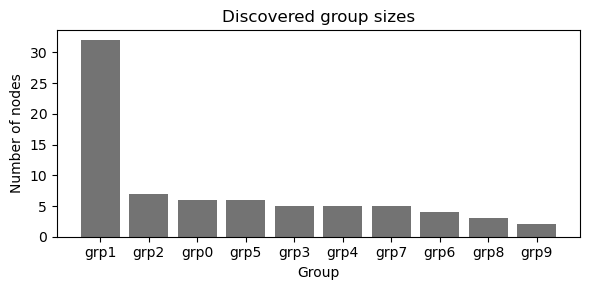

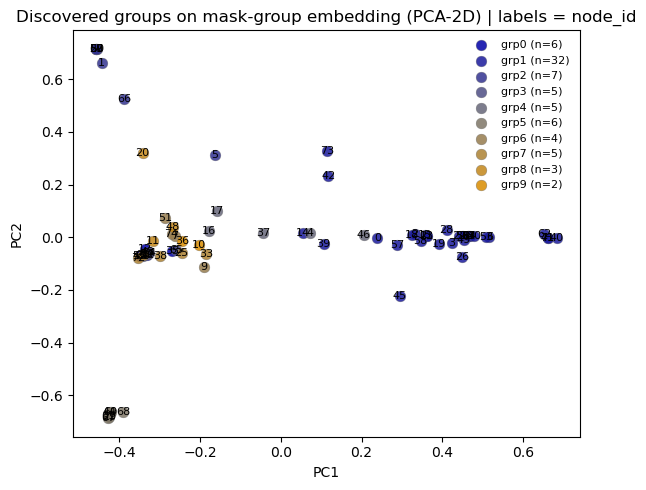

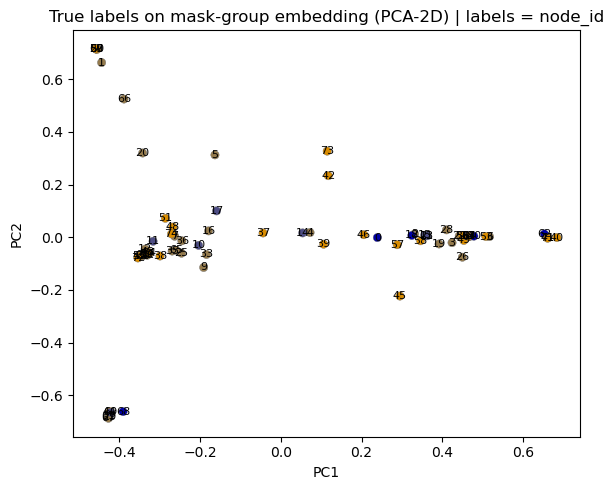

In [7]:
# --- Visualization: discovered mask-learned groups ---
from matplotlib.colors import ListedColormap
from viz.theme import EDGE_GRAY, categorical_palette

# Group sizes
plt.figure(figsize=(6, 3))
plt.bar([f"grp{int(g)}" for g in uniq[order]], cnt[order], color=EDGE_GRAY)
plt.title("Discovered group sizes")
plt.xlabel("Group")
plt.ylabel("Number of nodes")
plt.tight_layout()
plt.show()

# 2D projection of mask-group embedding (PCA-2D) used for clustering
# node_emb comes from mask-group random-walk embeddings
emb2 = node_embedding_to_plot2d(node_emb, seed=int(globals().get("seed", 0)))

node_ids = np.arange(n_nodes)

groups = uniq[np.argsort(uniq)]
group_colors = categorical_palette(len(groups))

plt.figure(figsize=(6, 5))
for i, g in enumerate(groups):
    idx = group_of == g
    plt.scatter(
        emb2[idx, 0],
        emb2[idx, 1],
        s=60,
        alpha=0.85,
        color=group_colors[i],
        edgecolor=EDGE_GRAY,
        linewidth=0.3,
        label=f"grp{int(g)} (n={int(idx.sum())})",
    )
annotate_scatter(emb2[:, 0], emb2[:, 1], labels=node_ids, fontsize=8)
plt.title("Discovered groups on mask-group embedding (PCA-2D) | labels = node_id")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(fontsize=8, frameon=False, loc="best")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
classes_y = np.sort(np.unique(y))
class_palette = categorical_palette(len(classes_y))
class_to_idx = {int(c): i for i, c in enumerate(classes_y)}
y_idx = np.asarray([class_to_idx[int(v)] for v in y], dtype=int)
plt.scatter(
    emb2[:, 0],
    emb2[:, 1],
    c=y_idx,
    cmap=ListedColormap(class_palette),
    edgecolor=EDGE_GRAY,
    linewidth=0.3,
)
annotate_scatter(emb2[:, 0], emb2[:, 1], labels=node_ids, fontsize=8)
plt.title("True labels on mask-group embedding (PCA-2D) | labels = node_id")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


In [8]:

# --- Train CBM head (val-selected hyperparameters, test reported after refit) ---
train_nodes_internal = np.asarray(train_nodes_internal, dtype=int)
val_nodes_internal = np.asarray(val_nodes_internal, dtype=int)
test_nodes_internal = np.asarray(test_nodes_internal, dtype=int)

X_train = C_full[train_nodes_internal]
y_train = y[train_nodes_internal]
X_test = C_full[test_nodes_internal]
y_test = y[test_nodes_internal]

print("Train:", X_train.shape, "| Val:", (C_full[val_nodes_internal].shape if val_nodes_internal.size else (0, C_full.shape[1])), "| Test:", X_test.shape)
print("Train label counts:", {int(k): int(v) for k, v in zip(*np.unique(y_train, return_counts=True))})
print("Val   label counts:", {int(k): int(v) for k, v in zip(*np.unique(y[val_nodes_internal], return_counts=True))} if val_nodes_internal.size else {})
print("Test  label counts:", {int(k): int(v) for k, v in zip(*np.unique(y_test, return_counts=True))})

if val_nodes_internal.size > 0:
    X_val = C_full[val_nodes_internal]
    y_val = y[val_nodes_internal]

    best_cfg, val_scores = tune_sparse_logreg_on_val(
        X_train,
        y_train,
        X_val,
        y_val,
        Cs=Cs,
        seed=seed,
        max_iter=MAX_ITER,
        l1_ratios=tuple(L1_RATIOS),
        target_active_concepts=int(TARGET_ACTIVE_CONCEPTS),
        diversity_weight=float(DIVERSITY_WEIGHT),
        class_weight_balanced=bool(HEAD_CLASS_WEIGHT_BALANCED),
    )

    print("Selected params on val:", best_cfg)
    print("Top val candidates (objective):")
    val_items = sorted(val_scores.items(), key=lambda kv: float(kv[1]["objective"]), reverse=True)
    for key, rec in val_items[: min(12, len(val_items))]:
        print(
            f"  {key:<22} | ba={rec['balanced_acc']:.4f} | obj={rec['objective']:.4f} "
            f"| mean_nnz={rec['mean_nnz']:.1f} | entropy={rec['coef_entropy']:.3f}"
        )

    # Report train/val on model fit only on train split.
    clf_train_only = make_sparse_logreg_clf(
        C=float(best_cfg["C"]),
        l1_ratio=float(best_cfg["l1_ratio"]),
        max_iter=MAX_ITER,
        seed=seed,
        class_weight_balanced=bool(HEAD_CLASS_WEIGHT_BALANCED),
    )
    clf_train_only.fit(X_train, y_train)

    pred_train_split = clf_train_only.predict(X_train)
    pred_val = clf_train_only.predict(X_val)
    ba_train_split = float(balanced_accuracy_score(y_train, pred_train_split))
    ba_val = float(balanced_accuracy_score(y_val, pred_val))

    # Final model is refit on train+val before touching test.
    train_plus_val_nodes_internal = np.concatenate([train_nodes_internal, val_nodes_internal]).astype(int)
    X_train_val = C_full[train_plus_val_nodes_internal]
    y_train_val = y[train_plus_val_nodes_internal]

    clf = make_sparse_logreg_clf(
        C=float(best_cfg["C"]),
        l1_ratio=float(best_cfg["l1_ratio"]),
        max_iter=MAX_ITER,
        seed=seed,
        class_weight_balanced=bool(HEAD_CLASS_WEIGHT_BALANCED),
    )
    clf.fit(X_train_val, y_train_val)

    pred_train = clf.predict(X_train_val)
    ba_train = float(balanced_accuracy_score(y_train_val, pred_train))
else:
    print("[warn] Validation split is empty. Falling back to CV-based tuning on train split.")
    clf, best_cfg, val_scores = tune_and_train_sparse_logreg_l1(
        X_train,
        y_train,
        Cs=Cs,
        n_splits=5,
        seed=seed,
        max_iter=MAX_ITER,
        l1_ratios=tuple(L1_RATIOS),
        target_active_concepts=int(TARGET_ACTIVE_CONCEPTS),
        diversity_weight=float(DIVERSITY_WEIGHT),
        class_weight_balanced=bool(HEAD_CLASS_WEIGHT_BALANCED),
    )
    pred_train = clf.predict(X_train)
    ba_train = float(balanced_accuracy_score(y_train, pred_train))
    ba_val = float("nan")

pred_test = clf.predict(X_test)
ba_test = float(balanced_accuracy_score(y_test, pred_test))

if val_nodes_internal.size > 0:
    print(f"Balanced accuracy  train(split)={ba_train_split:.4f}  val(split)={ba_val:.4f}")
print(f"Balanced accuracy  train(refit train+val)={ba_train:.4f}  test={ba_test:.4f}")

coef_abs_full = np.abs(np.asarray(clf.coef_, dtype=np.float64))
nnz = int((coef_abs_full > 1e-8).sum())
print(f"Active concept coefficients: {nnz}/{coef_abs_full.size}")

# Family-level coefficient mass (mean absolute weight over classes)
fam_mass = {}
coef_col = np.mean(np.abs(coef_abs_full), axis=0)
for j, nm in enumerate(concept_names):
    fam = _concept_family_key(str(nm))
    fam_mass[fam] = fam_mass.get(fam, 0.0) + float(coef_col[j])

print("Top concept families by |weight| mass:")
for fam, m in sorted(fam_mass.items(), key=lambda kv: -kv[1])[:10]:
    print(f"  {fam:<30} {m:.4f}")


Train: (41, 125) | Val: (11, 125) | Test: (23, 125)
Train label counts: {0: 4, 1: 6, 2: 15, 3: 16}
Val   label counts: {0: 1, 1: 2, 2: 4, 3: 4}
Test  label counts: {0: 3, 1: 3, 2: 8, 3: 9}


/Users/juliawenkmann/miniconda3/envs/graphs/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/juliawenkmann/miniconda3/envs/graphs/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/juliawenkmann/miniconda3/envs/graphs/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/juliawenkmann/miniconda3/envs/graphs/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' 

Selected params on val: {'C': 1.0, 'l1_ratio': 1.0, 'balanced_acc': 0.25, 'mean_nnz': 7.0, 'coef_entropy': 0.29224099099419876, 'objective': 0.27100516891894777}
Top val candidates (objective):
  C=1|l1_ratio=1.000     | ba=0.2500 | obj=0.2710 | mean_nnz=7.0 | entropy=0.292
  C=1|l1_ratio=0.800     | ba=0.2500 | obj=0.2688 | mean_nnz=10.0 | entropy=0.336
  C=0.316228|l1_ratio=0.800 | ba=0.2500 | obj=0.2592 | mean_nnz=3.0 | entropy=0.146
  C=10|l1_ratio=0.800    | ba=0.2500 | obj=0.2565 | mean_nnz=135.0 | entropy=0.726
  C=10|l1_ratio=1.000    | ba=0.2500 | obj=0.2558 | mean_nnz=75.0 | entropy=0.642
  C=3.16228|l1_ratio=0.800 | ba=0.2500 | obj=0.2550 | mean_nnz=46.0 | entropy=0.558
  C=3.16228|l1_ratio=1.000 | ba=0.2500 | obj=0.2541 | mean_nnz=25.0 | entropy=0.455
  C=0.1|l1_ratio=0.800   | ba=0.2500 | obj=0.2526 | mean_nnz=1.0 | entropy=-0.000
  C=0.1|l1_ratio=1.000   | ba=0.2500 | obj=0.2526 | mean_nnz=1.0 | entropy=-0.000
  C=0.01|l1_ratio=0.800  | ba=0.2500 | obj=0.2500 | mean_nnz=0

/Users/juliawenkmann/miniconda3/envs/graphs/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/juliawenkmann/miniconda3/envs/graphs/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/juliawenkmann/miniconda3/envs/graphs/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/juliawenkmann/miniconda3/envs/graphs/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'mult

Balanced accuracy  train(split)=0.3563  val(split)=0.2500
Balanced accuracy  train(refit train+val)=0.3467  test=0.2049
Active concept coefficients: 6/500
Top concept families by |weight| mass:
  in2_start_top_margin           0.4237
  direct_in                      0.2043
  in2_start_strength             0.1548
  direct_in_top_margin           0.1348
  direct_in_strength             0.1085
  direct_out                     0.0000
  direct_out_entropy             0.0000
  direct_out_top1_mass           0.0000
  in2_start                      0.0000
  in2_start_entropy              0.0000


In [9]:

# --- Global faithfulness audit (test split; top concepts vs random ablation) ---
import pandas as pd

# Evaluate only correctly predicted test nodes when possible (more stable interpretation).
pred_test_nodes = np.asarray(clf.predict(C_full[test_nodes_internal]), dtype=int)
correct_mask = pred_test_nodes == y[test_nodes_internal]
if np.any(correct_mask):
    eval_nodes = np.asarray(test_nodes_internal[correct_mask], dtype=int)
else:
    eval_nodes = np.asarray(test_nodes_internal, dtype=int)

# Keep a bounded set for runtime.
MAX_AUDIT_NODES = int(globals().get("FAITH_AUDIT_MAX_NODES", 20))
if eval_nodes.size > MAX_AUDIT_NODES:
    pick = np.linspace(0, eval_nodes.size - 1, num=MAX_AUDIT_NODES, dtype=int)
    eval_nodes = eval_nodes[pick]

_active_idx_faith, faith_rows, faith_summary = aggregate_faithfulness_report(
    clf,
    C_full,
    eval_nodes=eval_nodes,
    concept_names=concept_names,
    use_both_layout_concepts=USE_BOTH_LAYOUT_CONCEPTS,
    spring_layout_on_g2=SPRING_LAYOUT_ON_G2,
    view=FAITH_ACTIVE_VIEW,
    max_k=int(globals().get("FAITH_AUDIT_MAX_K", 18)),
    random_trials=32,
    random_seed=seed,
)

if len(faith_rows) == 0:
    print("Faithfulness audit could not compute any valid rows.")
    faith_audit_df = pd.DataFrame(columns=["node", "pred", "k_max", "auc_gap", "flip_score", "p_drop_gap", "margin_drop_gap"])
else:
    faith_audit_df = pd.DataFrame(faith_rows).sort_values(["auc_gap", "flip_score"], ascending=False).reset_index(drop=True)
    display(faith_audit_df.head(12))

print(
    f"Faithfulness summary | view={faith_summary.get('view')} | "
    f"nodes={faith_summary.get('n_nodes')} | "
    f"active_concepts={faith_summary.get('n_active_concepts')} | "
    f"mean_auc_gap={faith_summary.get('mean_auc_gap'):.4f} +/- {faith_summary.get('std_auc_gap'):.4f} | "
    f"mean_flip={faith_summary.get('mean_flip'):.4f} | "
    f"mean_p_drop_gap={faith_summary.get('mean_p_drop'):.4f} | "
    f"mean_margin_drop_gap={faith_summary.get('mean_margin_drop'):.4f}"
)

# Optionally auto-select a node for downstream visualizations.
if AUTO_SELECT_EXPLAIN_NODE and len(faith_rows) > 0:
    node_internal = int(faith_audit_df.iloc[0]["node"])
    print(f"Auto-selected node_internal={node_internal} (highest faithfulness AUC-gap in audit set).")


,node,pred,k_max,auc_gap,flip_score,p_drop_gap,margin_drop_gap
0,1,2,18,0.172464,0.611111,0.312457,1.939834
1,54,3,2,0.152339,0.500000,0.273131,1.143654
2,57,3,2,0.142766,0.000000,0.252853,1.082100
3,40,3,2,0.121155,0.000000,0.201246,0.834488
4,72,3,2,0.109452,0.000000,0.193214,0.784821
5,6,2,18,0.040024,0.611111,0.226818,1.652243
6,2,2,18,0.028849,0.611111,0.191189,1.449203


Faithfulness summary | view=all | nodes=7 | active_concepts=125 | mean_auc_gap=0.1096 +/- 0.0512 | mean_flip=0.3333 | mean_p_drop_gap=0.2358 | mean_margin_drop_gap=1.2695
Auto-selected node_internal=1 (highest faithfulness AUC-gap in audit set).


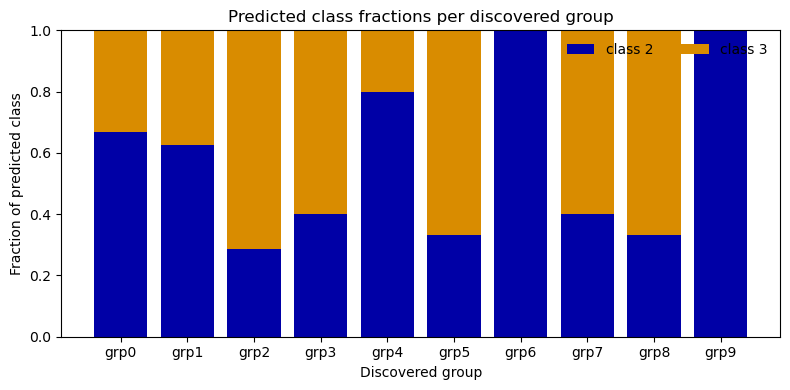

In [10]:
# --- Predicted class fractions per discovered group ---
from viz.theme import categorical_palette

# Use labeled nodes if the dataset has unlabeled ones (y < 0)
if "labeled_mask" in globals():
    mask = labeled_mask
else:
    mask = np.ones(n_nodes, dtype=bool)

pred_all = clf.predict(C_full)
pred_sel = pred_all[mask]
group_sel = group_of[mask]

classes = np.sort(np.unique(pred_sel))
groups = np.sort(np.unique(group_sel))

counts = np.zeros((len(groups), len(classes)), dtype=int)
for i, g in enumerate(groups):
    for j, c in enumerate(classes):
        counts[i, j] = int(np.sum((group_sel == g) & (pred_sel == c)))

# Convert counts to fractions per group
row_sums = counts.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
frac = counts / row_sums

plt.figure(figsize=(8, 4))
labels = [f"grp{int(g)}" for g in groups]
colors = categorical_palette(len(classes))
bottom = np.zeros(len(groups), dtype=float)

for j, c in enumerate(classes):
    plt.bar(labels, frac[:, j], bottom=bottom, color=colors[j], label=f"class {int(c)}")
    bottom += frac[:, j]

plt.ylim(0, 1)
plt.ylabel("Fraction of predicted class")
plt.xlabel("Discovered group")
plt.title("Predicted class fractions per discovered group")
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()


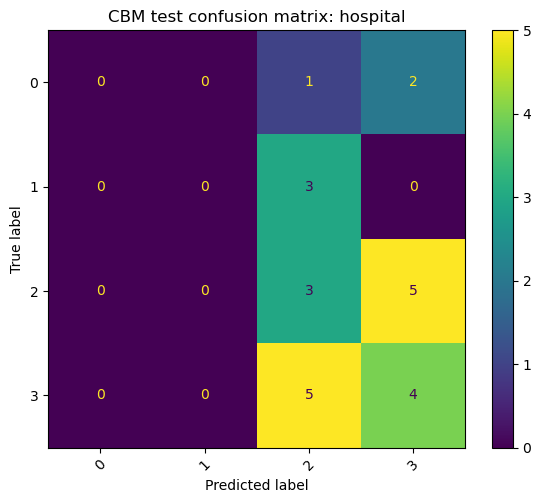

In [11]:

# --- Confusion matrix (test set) ---
cm = confusion_matrix(y_test, pred_test, labels=clf.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=clf.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
ax.set_title(f"CBM test confusion matrix: {dataset_key}")
plt.tight_layout()
plt.show()




Class 2 | n_test_pred=12
Top positive impacts (mean w*x):
  g__direct_in_grp0          mean w*x=0  w=0
  g2__in2_start_top_margin   mean w*x=0  w=0
  g2__in2_start_top1_mass    mean w*x=0  w=0
  g2__in2_start_entropy      mean w*x=0  w=0
  g2__in2_start_strength     mean w*x=0  w=0
  g2__in2_start_grp9         mean w*x=0  w=0
  g2__in2_start_grp8         mean w*x=0  w=0
  g2__in2_start_grp6         mean w*x=0  w=0
Top negative impacts (mean w*x):
  g__in2_start_top_margin    mean w*x=-0.7989  w=-1.695
  g__direct_in_grp0          mean w*x=0  w=0
  g2__in2_mid_grp0           mean w*x=0  w=0
  g2__in2_start_top_margin   mean w*x=0  w=0
  g2__in2_start_top1_mass    mean w*x=0  w=0
  g2__in2_start_entropy      mean w*x=0  w=0
  g2__in2_start_strength     mean w*x=0  w=0
  g2__in2_start_grp9         mean w*x=0  w=0


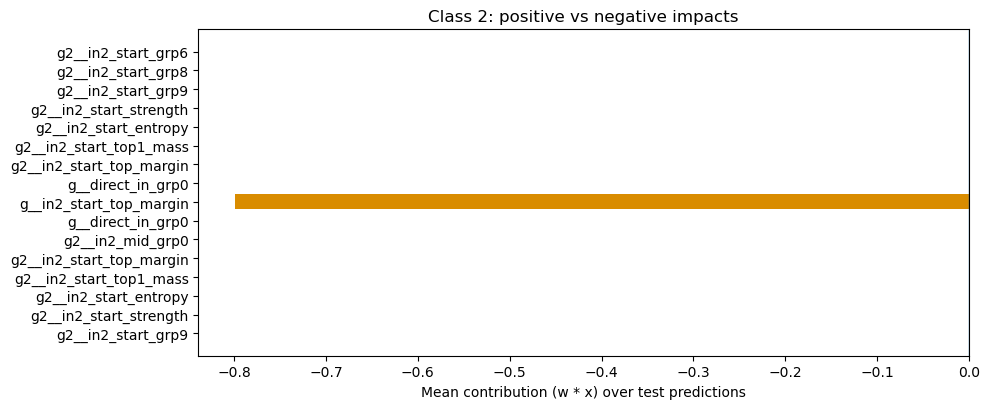


Class 3 | n_test_pred=11
Top positive impacts (mean w*x):
  g__direct_in_grp1          mean w*x=0.6616  w=0.8173
  g__direct_in_top_margin    mean w*x=0.3902  w=0.5392
  g__direct_in_grp0          mean w*x=0  w=0
  g2__in2_mid_grp0           mean w*x=0  w=0
  g2__in2_start_top_margin   mean w*x=0  w=0
  g2__in2_start_top1_mass    mean w*x=0  w=0
  g2__in2_start_entropy      mean w*x=0  w=0
  g2__in2_start_grp9         mean w*x=0  w=0
Top negative impacts (mean w*x):
  g2__in2_start_strength     mean w*x=-2.214  w=-0.6193
  g2__direct_in_strength     mean w*x=-0.9253  w=-0.1768
  g__direct_in_grp0          mean w*x=0  w=0
  g2__in2_start_top_margin   mean w*x=0  w=0
  g2__in2_start_top1_mass    mean w*x=0  w=0
  g2__in2_start_entropy      mean w*x=0  w=0
  g2__in2_start_grp9         mean w*x=0  w=0
  g2__in2_start_grp8         mean w*x=0  w=0


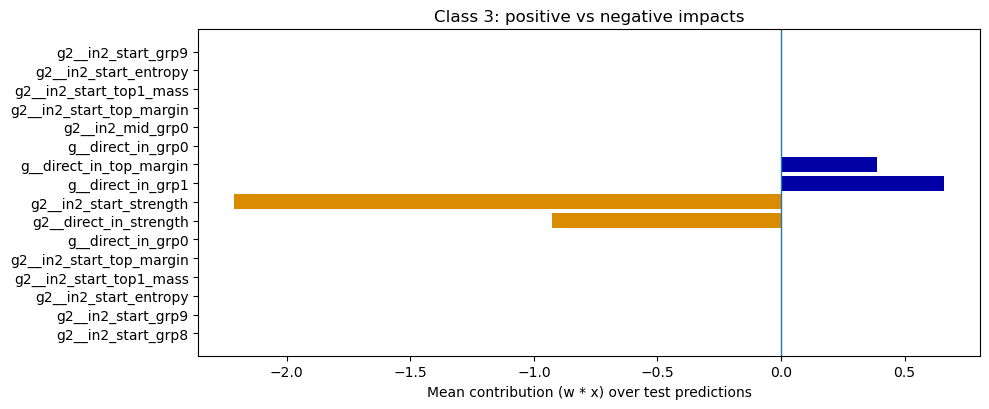

In [12]:
# --- Global concept impact per predicted class (on the test split) ---
classes = list(map(int, clf.classes_.tolist())) if hasattr(clf.classes_, "tolist") else list(map(int, clf.classes_))
TOPK_POS = 8
TOPK_NEG = 8

for c in classes:
    w, _b = _weights_for_class(clf, c)

    mask = (pred_test == c)
    n_sel = int(mask.sum())
    if n_sel == 0:
        continue

    X_sel = X_test[mask]
    contrib = X_sel * w
    mean_contrib = contrib.mean(axis=0)

    pos_idx = np.argsort(-mean_contrib)[:TOPK_POS]
    neg_idx = np.argsort(mean_contrib)[:TOPK_NEG]

    print(f"\nClass {c} | n_test_pred={n_sel}")
    print("Top positive impacts (mean w*x):")
    for j in pos_idx:
        j = int(j)
        print(f"  {concept_names[j]:<25}  mean w*x={mean_contrib[j]:.4g}  w={w[j]:.4g}")

    print("Top negative impacts (mean w*x):")
    for j in neg_idx:
        j = int(j)
        print(f"  {concept_names[j]:<25}  mean w*x={mean_contrib[j]:.4g}  w={w[j]:.4g}")

    neg_names = [concept_names[int(j)] for j in neg_idx][::-1]
    neg_vals = [mean_contrib[int(j)] for j in neg_idx][::-1]
    pos_names = [concept_names[int(j)] for j in pos_idx]
    pos_vals = [mean_contrib[int(j)] for j in pos_idx]

    names = neg_names + pos_names
    vals = neg_vals + pos_vals
    colors = _colors_by_sign(vals)

    plt.figure(figsize=(10, 4.2))
    plt.barh(range(len(vals)), vals, color=colors)
    plt.yticks(range(len(vals)), names)
    plt.axvline(0.0, linewidth=1)
    plt.xlabel("Mean contribution (w * x) over test predictions")
    plt.title(f"Class {c}: positive vs negative impacts")
    plt.tight_layout()
    plt.show()




Node (internal id) = 1
True label = 2 | Pred label = 2
Predicted probabilities:
  class 0: 0.1008
  class 1: 0.1235
  class 2: 0.5300
  class 3: 0.2457


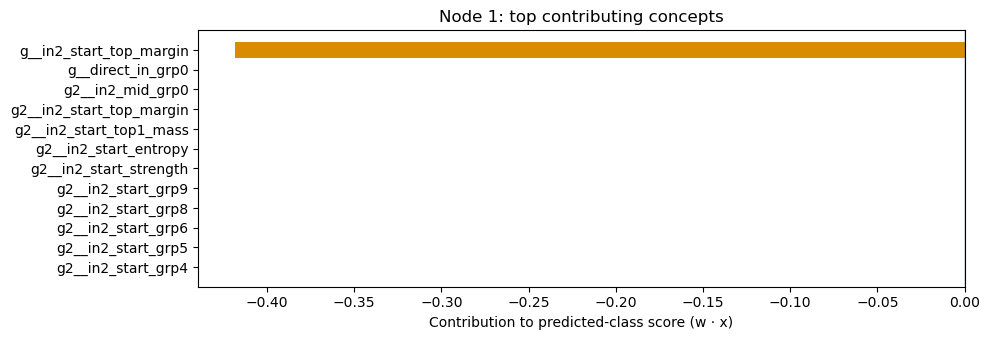

In [13]:

# --- Explain one prediction (pick a node from the test set) ---
if "node_internal" not in globals():
    i = 0  # change to inspect a different node in the test set
    node_internal = int(test_nodes_internal[i])

true_label = int(y[node_internal])
pred_label = int(clf.predict(C_full[node_internal][None, :])[0])

expl = explain_node_prediction(clf, C_full, concept_names, node_internal, topk=12)

print(f"Node (internal id) = {node_internal}")
print(f"True label = {true_label} | Pred label = {pred_label}")
if expl["proba"] is not None:
    # print in a stable order = clf.classes_
    p = expl["proba"]
    print("Predicted probabilities:")
    for cid, pv in zip(clf.classes_, p):
        print(f"  class {int(cid)}: {float(pv):.4f}")

plot_explanation(expl, title=f"Node {node_internal}: top contributing concepts")



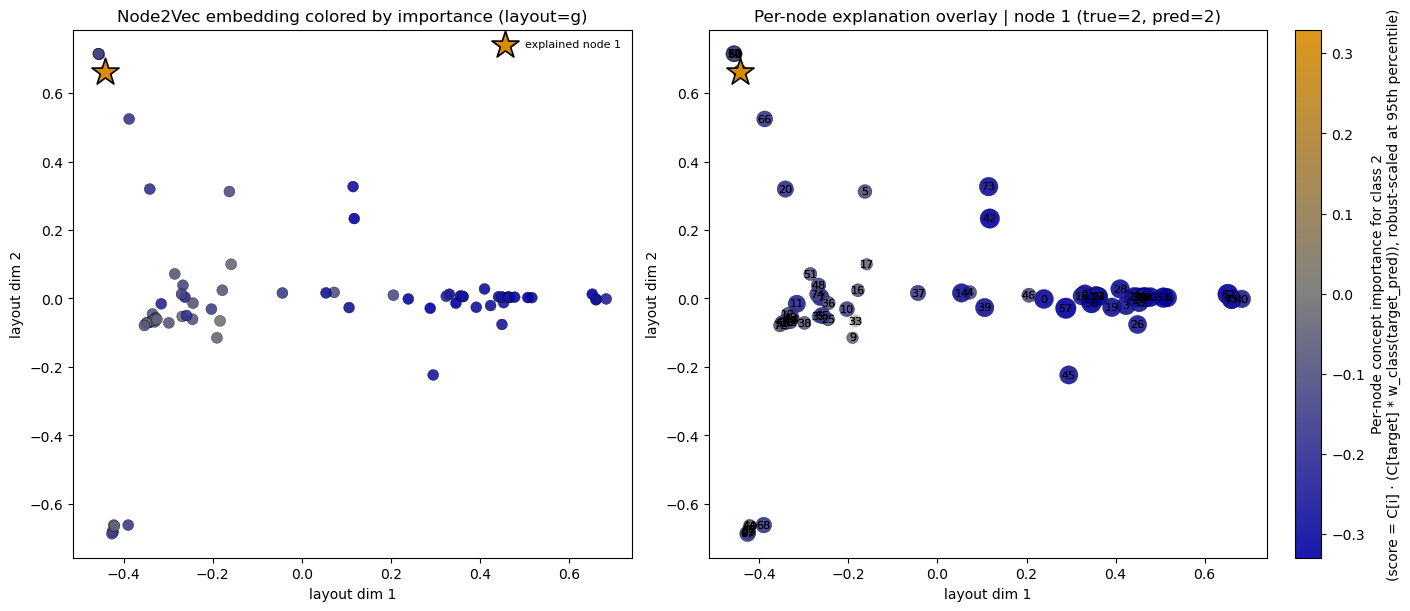

Active concept view: both-layout/g
Per-node score mode: all active concepts | SCORE_MODE=target_overlap
Score formula: C[i] · (C[target] * w_class(target_pred))
Top nodes by |per-node score|:
  node  57: score=-0.3779 | group=grp1 | true=3 | pred=3
  node  62: score=-0.3587 | group=grp1 | true=0 | pred=3
  node  53: score=-0.3372 | group=grp1 | true=3 | pred=3
  node  58: score=-0.3326 | group=grp1 | true=3 | pred=3
  node  63: score=-0.3280 | group=grp1 | true=0 | pred=3
  node  42: score=-0.3200 | group=grp1 | true=3 | pred=3
  node  70: score=-0.3030 | group=grp1 | true=0 | pred=3
  node   0: score=-0.3015 | group=grp1 | true=0 | pred=2
  node  15: score=-0.2985 | group=grp1 | true=1 | pred=2
  node   8: score=-0.2945 | group=grp1 | true=1 | pred=2


In [14]:
# --- Visualization: explanation on mask-group embedding (PCA-2D) (target node as star) ---
from viz import run_embedding_explanation_map

run_embedding_explanation_map(globals())


In [15]:
print("min,max =", float(node_score.min()), float(node_score.max()))
print("frac negative =", float((node_score < 0).mean()))



min,max = -0.37794163823127747 0.0
frac negative = 0.9866666666666667


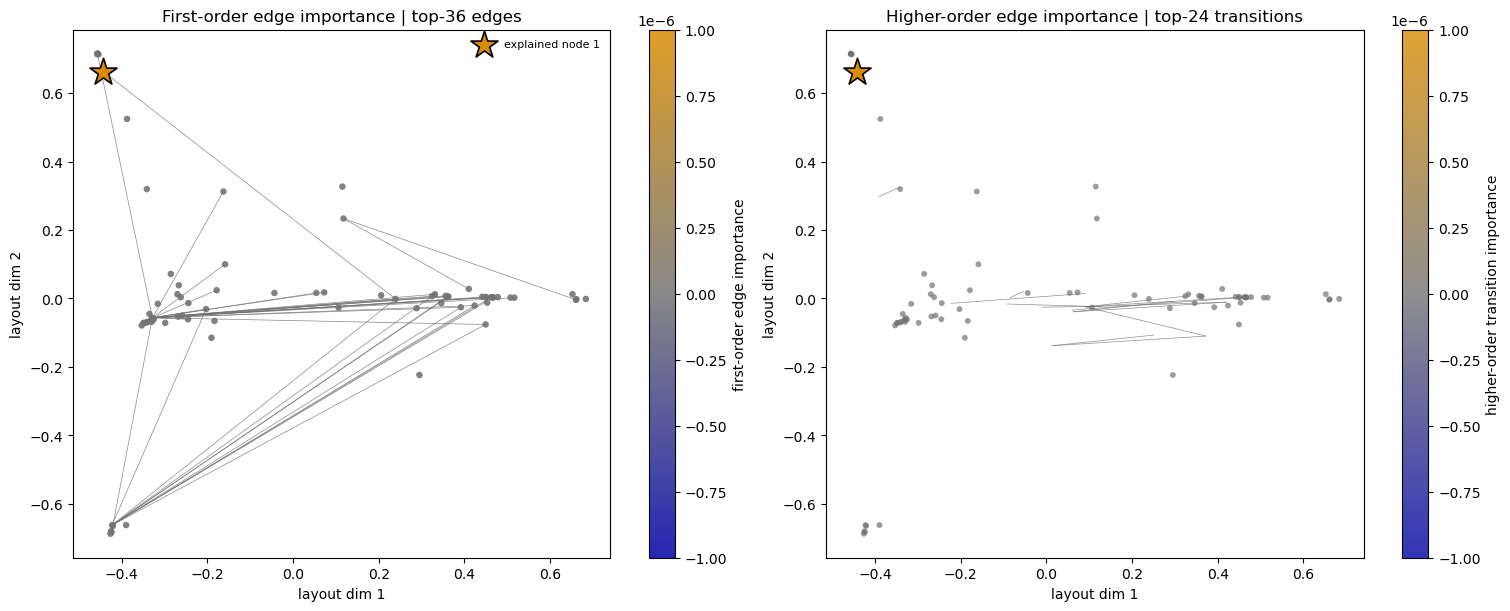

Edge score mode: target_overlap
Score formula: C[node] * (C[target] * w_class(target_pred))
Active concept view: both-layout/g
FO threshold |score| >= 0 | HO threshold |score| >= 0
FO edges plotted: 36/2278 | robust vmax=0.0000
HO edges plotted: 24/9349 | robust vmax=0.0000

Top first-order edges by |importance|:
   1. (  0 ->   1)  score=+0.0000  g_u=grp1 g_v=grp2
   2. ( 44 ->  13)  score=+0.0000  g_u=grp5 g_v=grp1
   3. ( 44 ->  10)  score=+0.0000  g_u=grp5 g_v=grp9
   4. ( 44 ->   8)  score=+0.0000  g_u=grp5 g_v=grp1
   5. ( 44 ->   3)  score=+0.0000  g_u=grp5 g_v=grp1
   6. ( 44 ->   2)  score=+0.0000  g_u=grp5 g_v=grp1
   7. ( 44 ->   0)  score=+0.0000  g_u=grp5 g_v=grp1
   8. ( 43 ->  56)  score=+0.0000  g_u=grp0 g_v=grp1
   9. ( 43 ->  34)  score=+0.0000  g_u=grp0 g_v=grp1
  10. ( 43 ->  30)  score=+0.0000  g_u=grp0 g_v=grp1

Top higher-order transitions by |importance|:
   1. (  0->  2) -> (  2->  0)  score=+0.0000
   2. ( 35-> 19) -> ( 19-> 35)  score=+0.0000
   3. ( 35-> 19)

In [16]:
# --- Visualization: first-order vs higher-order edge importance (concept-based) ---
from viz import run_first_vs_higher_order_importance

run_first_vs_higher_order_importance(globals())


In [17]:
for fam in ["direct_in","direct_out","in2_start","in2_mid","out2_end","out2_mid"]:
    idx = [i for i,n in enumerate(active_names) if n.startswith(fam + "_grp")]
    if not idx:
        continue
    print(
        fam,
        "mean|w_eff|=", float(np.mean(np.abs(w_eff[idx]))),
        "target_mean=", float(np.mean(C_active[node_internal, idx]))
    )



direct_in mean|w_eff|= 0.0 target_mean= 0.0980902761220932
direct_out mean|w_eff|= 0.0 target_mean= 0.10127314925193787
in2_start mean|w_eff|= 0.0 target_mean= 0.10000000149011612
in2_mid mean|w_eff|= 0.0 target_mean= 0.09999998658895493
out2_end mean|w_eff|= 0.0 target_mean= 0.10000000149011612
out2_mid mean|w_eff|= 0.0 target_mean= 0.10000000149011612


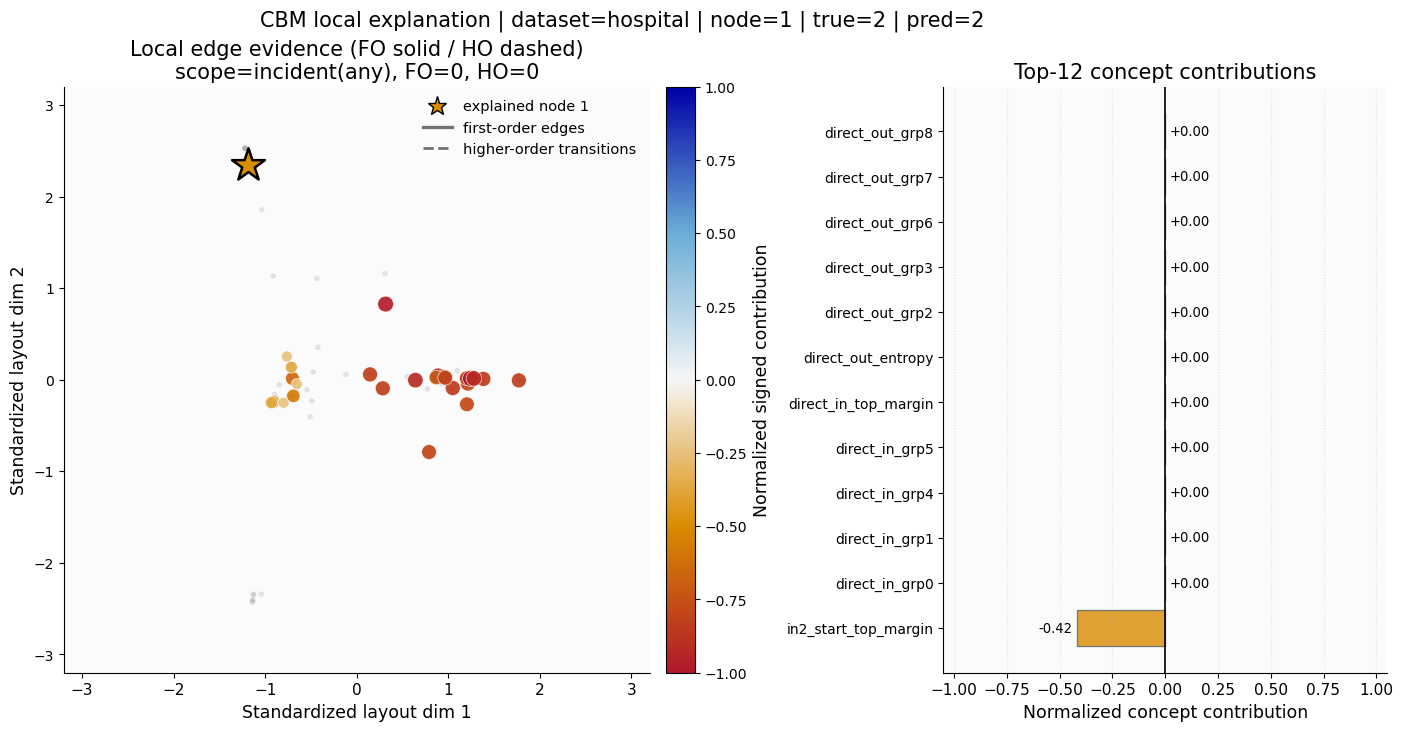

Edge score mode: target_overlap
Score formula: C[node] * (C[target] * w_class(pred))
Active concept view: both-layout/g
Edge filters (normalized): FO |score| >= 0.060, HO |score| >= 0.060
FO edges shown: 0/2278 | HO transitions shown: 0/9349
[saved figure] /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/IV_cbm_implementation/plots/hospital_local_explanation_node1_pred2.pdf


In [18]:
# --- Visualization: LOCAL edge importance around explained node (k-hop / incident) ---
from viz import run_local_edge_importance

run_local_edge_importance(globals())


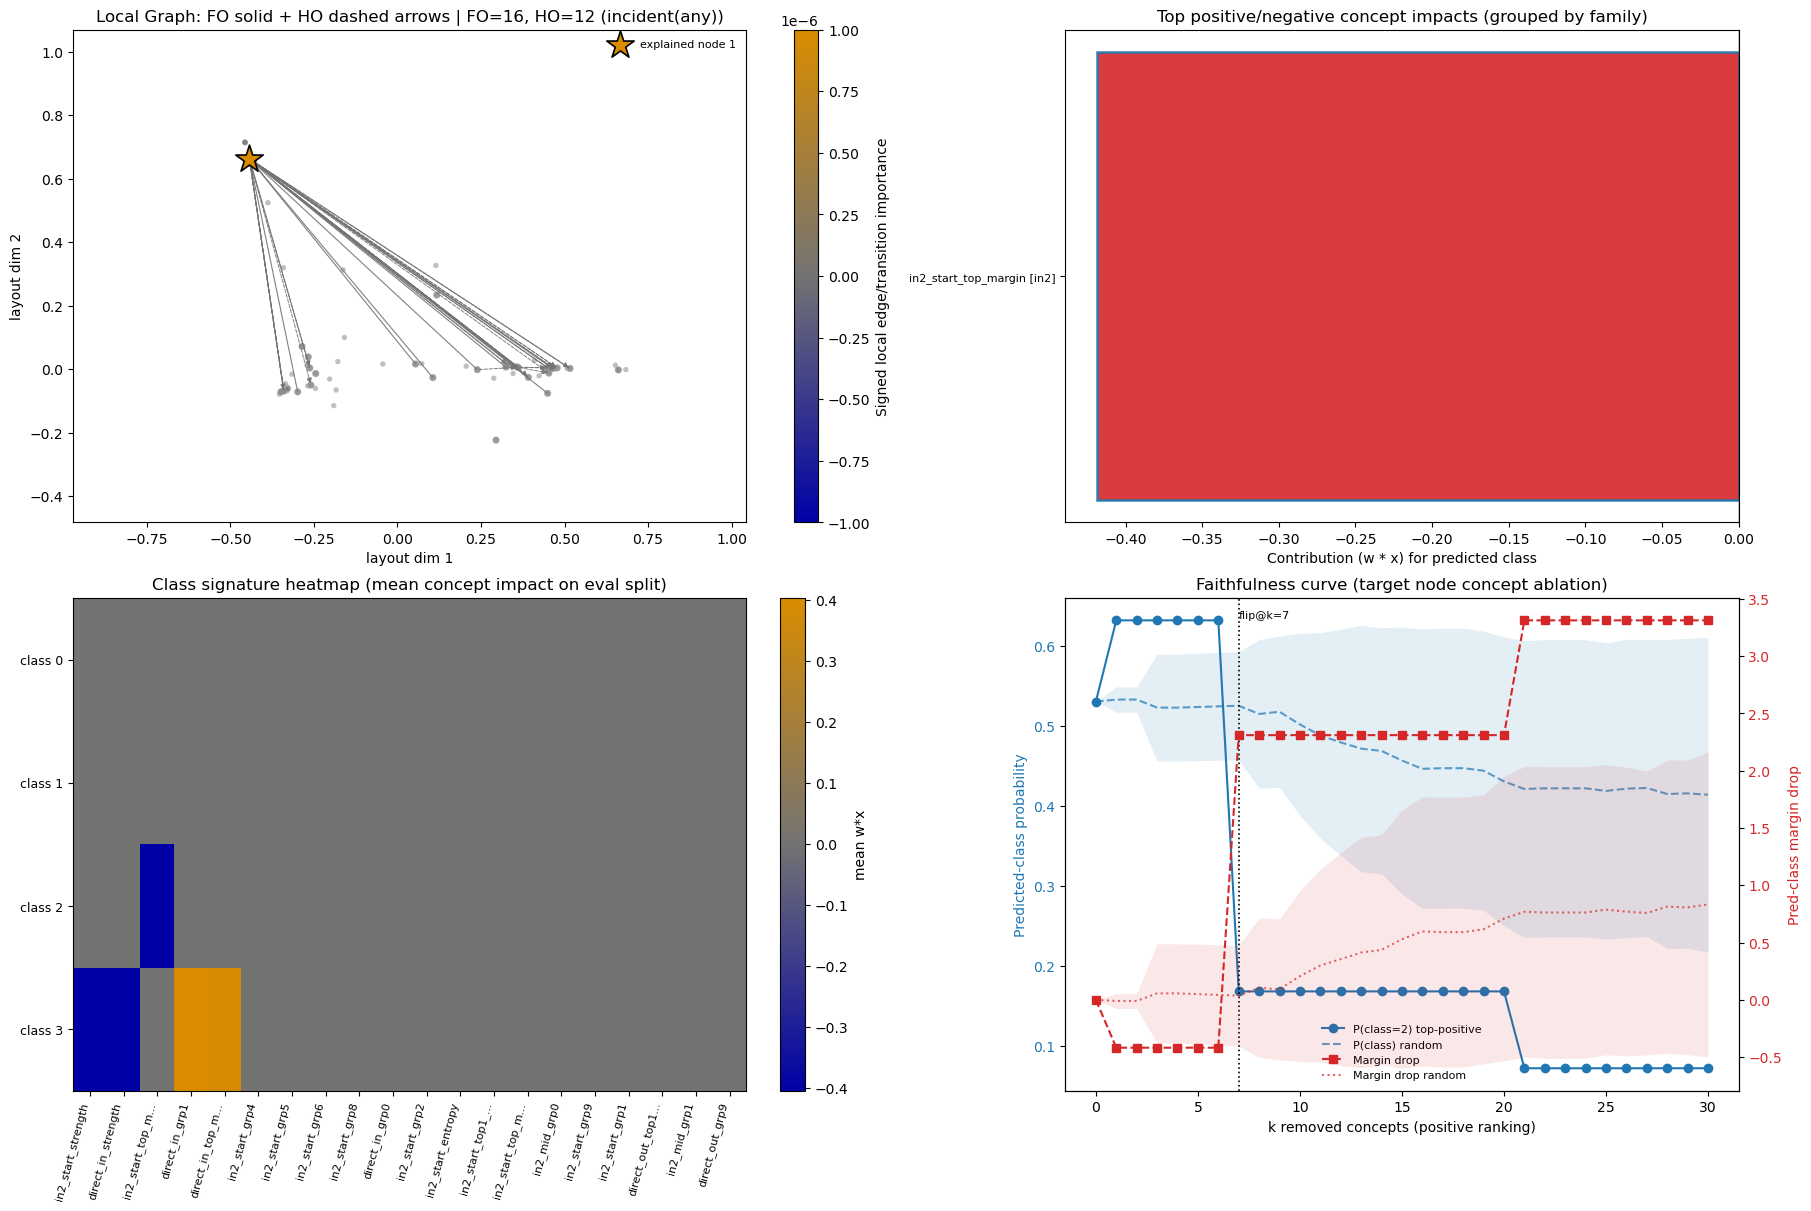

Dashboard target node: 1 | true=2 | pred=2
Score mode: target_overlap | formula: C[i] * (C[target] * w_class(target_pred))
Concept view: local=all, faith=all
Local graph settings: scope=incident, ho_scope=incident(any), FO shown=16, HO shown=12
Faithfulness: mode=positive, k_max=30, flip_k=7, p_end=0.0720 vs random=0.4137, margin_drop_end=3.3126 vs random=0.8318


In [19]:
# --- CBM explanation dashboard (2x2): local graph, concept waterfall, class heatmap, faithfulness ---
from viz import run_explanation_dashboard

run_explanation_dashboard(globals())


Non-zero units: 5/73
Node=1 | true=2 | pred=2 | mode=joint_duplicates | base P(pred)=0.5300 | base margin=0.7686

Top units that hurt prediction most when ablated:


,unit,n_concepts,sum_w*x,delta_p_pred,delta_margin,flip,members
43,in2_start_strength,1,0.000000,0.412703,2.728933,1,g2__in2_start_strength
7,direct_in_strength,1,0.000000,0.131178,1.002056,1,g2__direct_in_strength
8,direct_in_top_margin,2,0.000000,-0.010269,-0.080499,0,g__direct_in_top_margin | g2__direct_in_top_ma...
2,direct_in_grp1,2,0.000000,-0.031718,-0.261078,0,g__direct_in_grp1 | g2__direct_in_grp1
45,in2_start_top_margin,2,-0.418435,-0.101481,-0.418435,0,g__in2_start_top_margin | g2__in2_start_top_ma...



Units that help when ablated (contradictory features):


,unit,n_concepts,sum_w*x,delta_p_pred,delta_margin,flip,members
43,in2_start_strength,1,0.000000,0.412703,2.728933,1,g2__in2_start_strength
7,direct_in_strength,1,0.000000,0.131178,1.002056,1,g2__direct_in_strength
8,direct_in_top_margin,2,0.000000,-0.010269,-0.080499,0,g__direct_in_top_margin | g2__direct_in_top_ma...
2,direct_in_grp1,2,0.000000,-0.031718,-0.261078,0,g__direct_in_grp1 | g2__direct_in_grp1
45,in2_start_top_margin,2,-0.418435,-0.101481,-0.418435,0,g__in2_start_top_margin | g2__in2_start_top_ma...


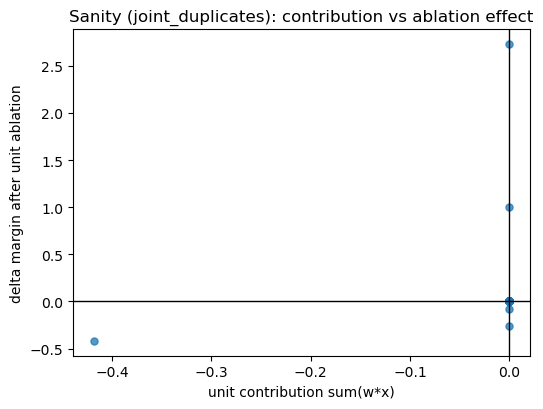

In [20]:
# --- Sanity check: concept ablation impact on one node (single or joint-duplicate groups) ---
from viz import run_ablation_sanity_check

run_ablation_sanity_check(globals())


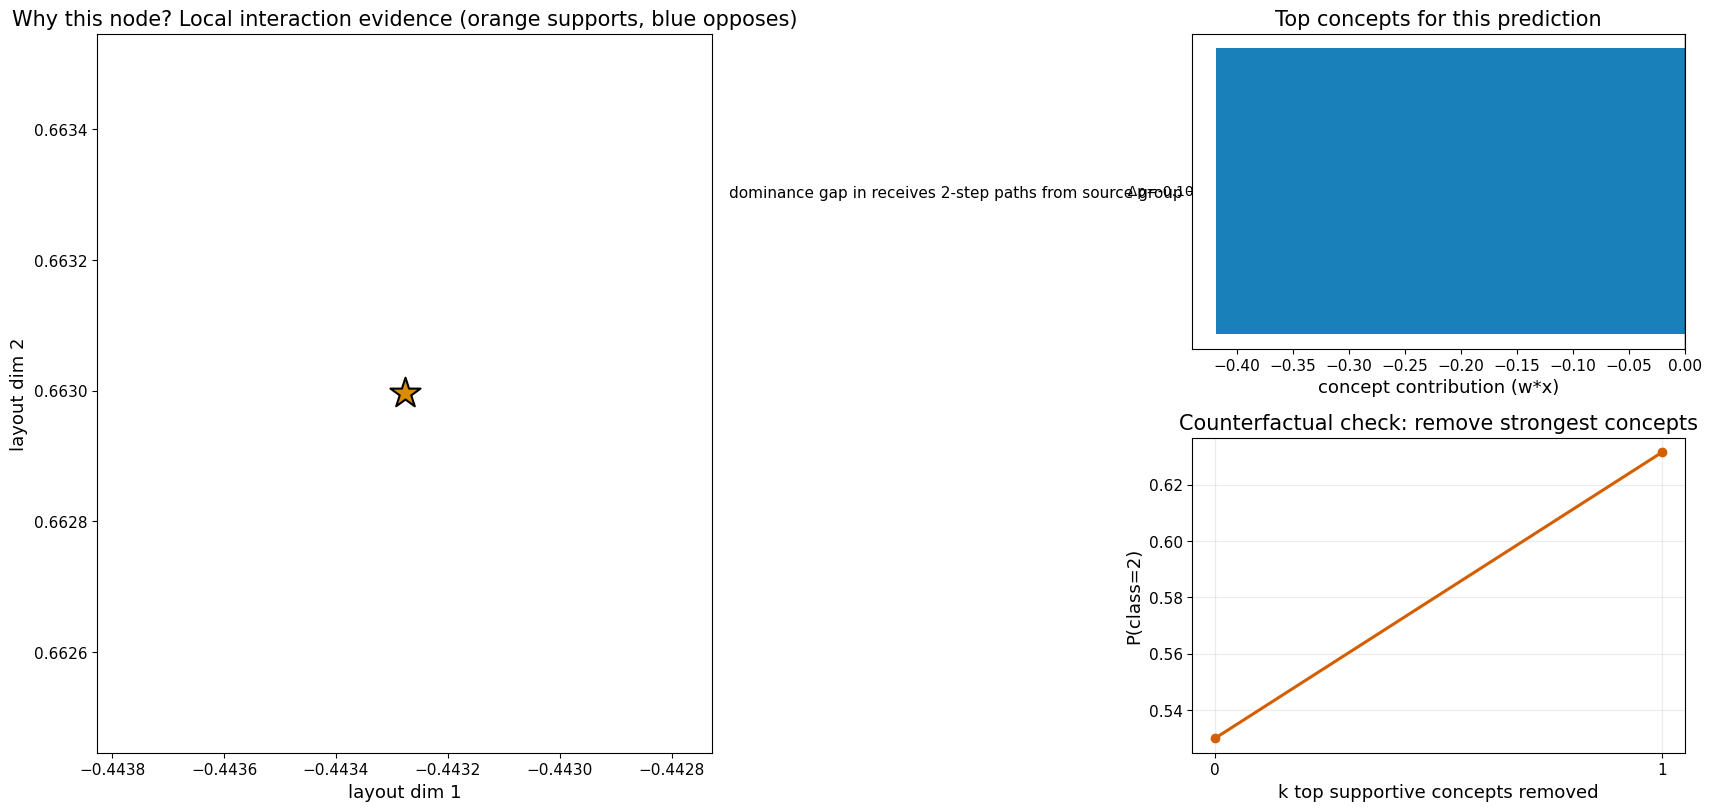

[saved figure] /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/IV_cbm_implementation/plots/hospital_faithfulness_curve_node1_pred2.pdf
Node 1 predicted class 2 (probability=0.530).
Main reasons (highest positive concept contributions):
Concepts that push against this class:
  - dominance gap in receives 2-step paths from source group: contribution=-0.418


In [21]:
# --- Human-readable explanation card (non-expert friendly) ---
from viz import run_human_readable_explanation_card

run_human_readable_explanation_card(globals())


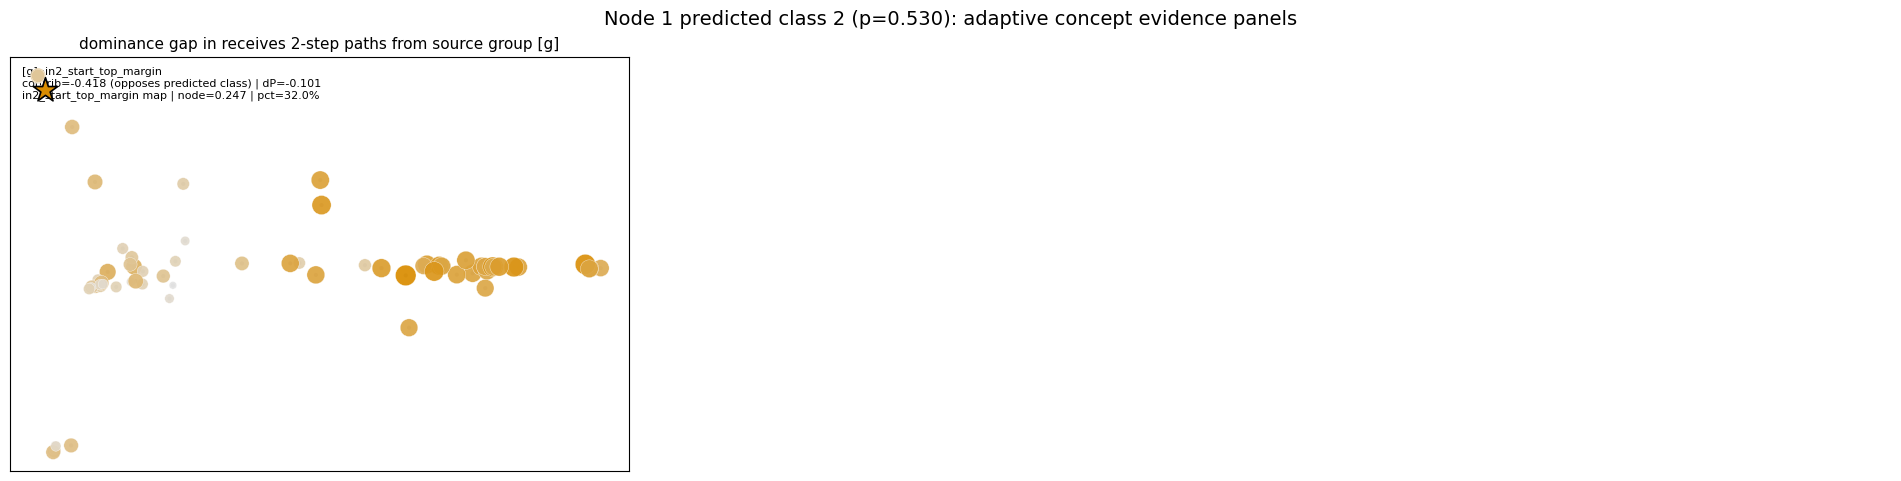

Adaptive concept panels for node 1:
  - dominance gap in receives 2-step paths from source group | contribution=-0.418 | dP=-0.101


In [22]:
# --- Adaptive concept maps (auto-selected from top supportive/opposing concepts) ---
from viz import run_adaptive_concept_maps

run_adaptive_concept_maps(globals())


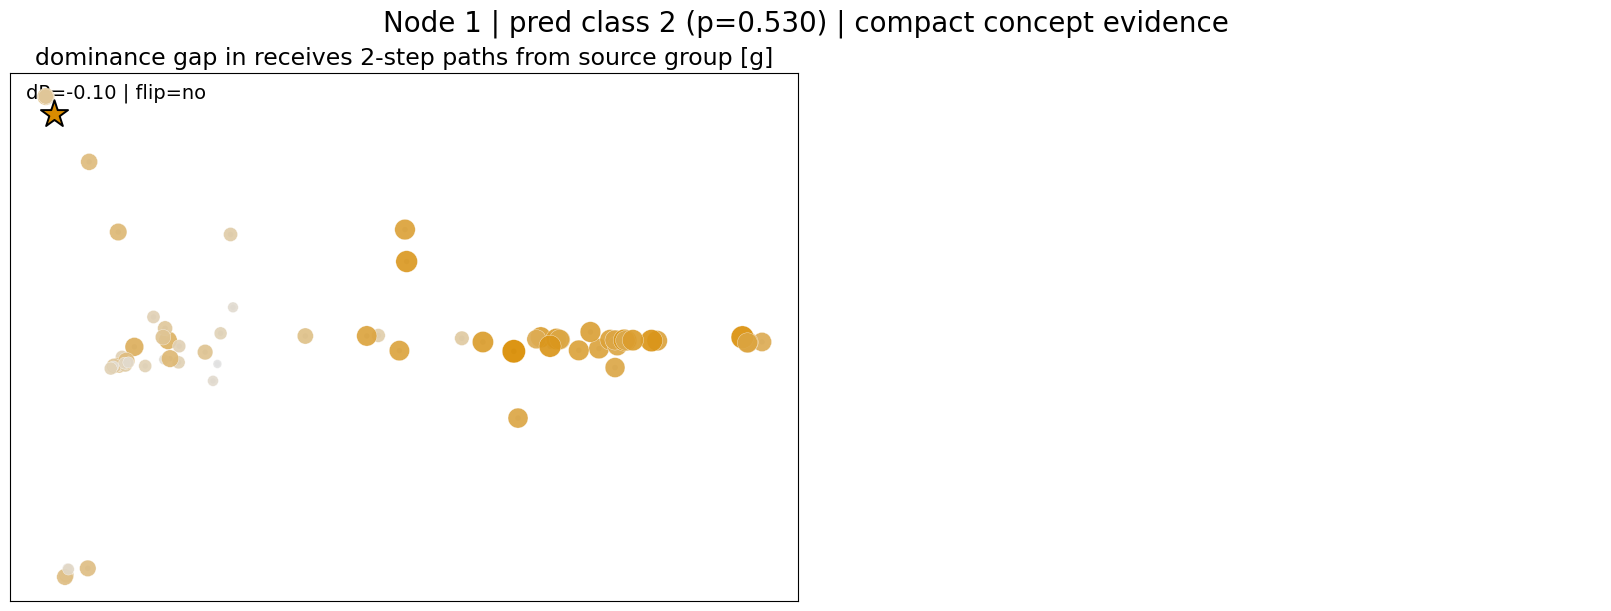

[saved compact figure] /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/IV_cbm_implementation/plots/hospital_adaptive_panels_compact_node1_pred2.pdf
Compact adaptive panels for node 1:
  - dominance gap in receives 2-step paths from source group | w*x=-0.418 | dP=-0.10


In [23]:
# --- Adaptive concept maps (PDF-friendly compact version: less text, bigger fonts) ---
from viz import run_adaptive_concept_maps_compact

run_adaptive_concept_maps_compact(globals())


## How to Read the Concept Explanation (Plain Language)

When the notebook prints lines like:

- `sends interactions to 1: contribution=+4.871, Δp=+0.829 | flips class when removed`
- `receives 2-step paths through middle group 1: contribution=+1.582, Δp=+0.035`
- `focus on one dominant incoming group: contribution=-0.392`

use this interpretation:

- `contribution = w * x`:
  `w` is the model weight for this concept and `x` is this node's concept value.
  Positive values support the predicted class; negative values push against it.
- `Δp`:
  change in predicted-class probability when this concept is removed (set to zero for this node).
  Larger positive `Δp` means the concept is causally important for the current prediction.
- `flips class when removed`:
  removing that concept changes the predicted label, so that concept is critical.

### Meaning of the concept phrases

- `sends interactions to k` (`direct_out_grpk`):
  this node tends to send first-order interactions toward nodes in discovered group `k`.
- `receives interactions from k` (`direct_in_grpk`):
  this node tends to receive first-order interactions from group `k`.
- `receives 2-step paths through middle group k` (`in2_mid_grpk`):
  among two-step temporal paths ending at this node, the middle node is often in group `k`.
- `receives 2-step paths from source group k` (`in2_start_grpk`):
  two-step temporal paths ending here often start from a node in group `k`.
- `overall incoming interaction volume` (`direct_in_strength`):
  total incoming first-order activity level (regardless of group).
- `focus on one dominant ...` (`*_top1_mass`):
  how concentrated the distribution is on one dominant group.
- `dominance gap in ...` (`*_top_margin`):
  gap between the largest and second-largest group mass.

### Interpreting your Node 36 example

- Prediction: class `0` with probability `0.991`.
- Strongest supporting concept:
  `sends interactions to 1` with `contribution=+4.871` and `Δp=+0.829`.
  This is a major reason for class `0`; removing it alone flips the class.
- Additional support comes from:
  `receives 2-step paths through middle group 1`, `receives interactions from 1`, and high incoming volume.
- Opposing evidence also exists:
  concepts with negative contribution (for example `dominance gap ...`, `in2_start_grp4`, `top1_mass ...`) pull away from class `0`.

So this prediction is not explained by one feature only: one concept is dominant, several secondary concepts support it, and a few concepts oppose it.
